# Heston real-market limitations diagnostics

This private notebook is designed to answer a very specific question:

**How does standard Heston fail, or become fragile, on real-market option-chain validation bundles?**

It is meant to generate the evidence needed for a short public note such as:

`docs/model_validation/heston_real_market_notes.md`

The purpose is not to make Heston fit every chain. The purpose is to classify failure modes honestly:

- boundary pressure, especially `kappa` near its upper bound;
- high `eta` / vol-of-vol pressure;
- weak or violated Feller diagnostics;
- objective sensitivity;
- train/holdout degradation;
- residual concentration by maturity, moneyness, side, spread, or vega;
- maturity-universe sensitivity;
- kappa weak identification.

## Design constraints

- **No random option-chain selection.** Bundles are discovered from saved model-validation artifacts and selected by deterministic validity/quality rules.
- **No random holdout split.** Holdouts are selected by a stable hash over quote identity, stratified by expiry and option side.
- **No provider calls.** The notebook reads already-saved local/private artifacts only.
- **No raw data redistribution.** Generated docs should be manually sanitized before committing if they were derived from licensed provider data.

## 0. Configuration

In [1]:
import os
import sys
from pathlib import Path

DEFAULT_PROJECT_ROOT = Path(r"C:\Users\ouwez\Documents\Quant\option-pricing-library")

PROJECT_ROOT = Path(os.environ.get("OPL_PROJECT_ROOT", str(DEFAULT_PROJECT_ROOT))).expanduser()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = Path.cwd()

DATA_ROOT = Path(os.environ.get("OPL_DATA_ROOT", str(PROJECT_ROOT / "data"))).expanduser()
MODEL_VALIDATION_ROOT = Path(
    os.environ.get(
        "OPL_MODEL_VALIDATION_ROOT",
        str(DATA_ROOT / "gold" / "model_validation_bundle"),
    )
).expanduser()

SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

# Set [] to auto-discover all valid underlyings.
UNDERLYINGS: list[str] = ["SPY", "QQQ", "IWM", "MSFT", "NVDA", "TSLA"]

# Deterministic bundle/quote selection controls.
SELECTION_MODE = "latest_valid_per_underlying"  # or "all_valid"
MIN_QUOTES = 80
MIN_EXPIRIES = 3
MIN_QUOTES_PER_RIGHT = 20
MIN_EXPIRY_DAYS = 7.0
MAX_EXPIRY_DAYS = 180.0
MAX_ABS_LOG_MONEYNESS = 0.35
MAX_RELATIVE_SPREAD = 0.35
MAX_QUOTES_TOTAL = 900
MAX_QUOTES_PER_EXPIRY_RIGHT = 80

# Calibration controls.
OBJECTIVE_TYPES = ("price_rmse", "vega_scaled_price", "bid_ask_normalized")
PRIMARY_OBJECTIVE_TYPE = "price_rmse"
MAX_SEEDS = 8
MAX_NFEV = 600
USE_ANALYTIC_JAC = True
BOUNDARY_TOLERANCE = 1.0e-3
ETA_HIGH_THRESHOLD = 3.0
HOLDOUT_FRACTION = 0.25

# Diagnostic sweeps.
RUN_BASELINE_OBJECTIVE_SWEEP = True
RUN_KAPPA_BOUND_LADDER = True
RUN_NESTED_MATURITY_EXCLUSION = True
RUN_ERROR_DECOMPOSITION = True
RUN_OBJECTIVE_SLICE_REVIEW = True

KAPPA_UPPER_GRID = (5.0, 10.0, 20.0, 40.0, 80.0)
NESTED_MIN_T_DAYS = (1.0, 7.0, 14.0, 30.0, 45.0, 60.0)

# Kappa profile is included in baseline diagnostics. Conditional refit is slower.
KAPPA_PROFILE_REFIT_REMAINING = False
KAPPA_PROFILE_MAX_NFEV = 250

# Default writes to out/ so you do not accidentally commit provider-derived conclusions.
WRITE_DOC_DRAFT = True
DOC_OUTPUT_PATH = PROJECT_ROOT / "out" / "heston_real_market_notes_draft.md"
# After manual review/sanitization you can switch to:
# DOC_OUTPUT_PATH = PROJECT_ROOT / "docs" / "model_validation" / "heston_real_market_notes.md"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("MODEL_VALIDATION_ROOT:", MODEL_VALIDATION_ROOT)
print("UNDERLYINGS:", UNDERLYINGS or "auto-discover all valid")


PROJECT_ROOT: C:\Users\ouwez\Documents\Quant\option-pricing-library
DATA_ROOT: C:\Users\ouwez\Documents\Quant\option-pricing-library\data
MODEL_VALIDATION_ROOT: C:\Users\ouwez\Documents\Quant\option-pricing-library\data\gold\model_validation_bundle
UNDERLYINGS: ['SPY', 'QQQ', 'IWM', 'MSFT', 'NVDA', 'TSLA']


## 1. Imports

The notebook uses the library's current Heston stack rather than ad hoc calibration code.

In [2]:

import json
import traceback
import warnings
from dataclasses import dataclass
from hashlib import sha256
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from option_pricing.diagnostics.heston import (
    heston_calibration_fit_summary,
    run_heston_calibration_fit_diagnostics,
)
from option_pricing.marketdata.gold import (
    heston_quote_set_from_frame,
    market_data_snapshot_from_json,
)
from option_pricing.models.heston.calibration import (
    HestonCalibrationBounds,
    calibrate_heston_multistart,
    preflight_heston_quotes,
)
from option_pricing.models.heston.calibration.heston_types import HestonQuoteSet
from option_pricing.types import MarketData

pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 240)
warnings.filterwarnings("default")

print("Imports loaded from:", SRC)


Imports loaded from: C:\Users\ouwez\Documents\Quant\option-pricing-library\src


## 2. Discover model-validation bundles

The notebook only considers saved model-validation bundles with the expected artifact shape:

- `manifest.json`
- `market_data.json`
- `heston_quotes.parquet`

Optional files such as `cleaned_quotes.parquet`, `rejected_quotes.parquet`, `surface_inputs.parquet`, `heston_fit_summary.csv`, and `warnings.json` are loaded when present.

In [3]:
REQUIRED_BUNDLE_FILES = ("manifest.json", "market_data.json", "heston_quotes.parquet")
OPTIONAL_BUNDLE_FILES = (
    "cleaned_quotes.parquet",
    "rejected_quotes.parquet",
    "surface_inputs.parquet",
    "heston_fit_summary.csv",
    "warnings.json",
)


def _parse_partition_value(path: Path, prefix: str) -> str | None:
    marker = prefix + "="
    for part in path.parts:
        if part.startswith(marker):
            return part[len(marker):]
    return None


def _candidate_manifest_paths(root: Path) -> list[Path]:
    root = root.expanduser()
    candidates: list[Path] = []

    if (root / "manifest.json").exists():
        candidates.append(root / "manifest.json")

    for pattern in (
        "underlying=*/date=*/run_id=*/manifest.json",
        "model_validation_bundle/underlying=*/date=*/run_id=*/manifest.json",
        "gold/model_validation_bundle/underlying=*/date=*/run_id=*/manifest.json",
    ):
        candidates.extend(root.glob(pattern))

    out: list[Path] = []
    seen: set[Path] = set()
    for path in candidates:
        resolved = path.resolve()
        if resolved not in seen:
            out.append(path)
            seen.add(resolved)
    return out


def discover_bundle_dirs(roots: list[Path]) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    for root in roots:
        for manifest_path in _candidate_manifest_paths(root):
            bundle_dir = manifest_path.parent
            try:
                manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
                manifest_error = ""
            except Exception as exc:
                manifest = {}
                manifest_error = f"{type(exc).__name__}: {exc}"

            underlying = (
                str(manifest.get("underlying") or "")
                or (_parse_partition_value(bundle_dir, "underlying") or "")
            )
            date_value = (
                str(manifest.get("valuation_timestamp_utc") or "")[:10]
                or (_parse_partition_value(bundle_dir, "date") or "")
            )
            run_id = (
                str(manifest.get("run_id") or "")
                or (_parse_partition_value(bundle_dir, "run_id") or "")
            )
            missing_required = [
                name for name in REQUIRED_BUNDLE_FILES if not (bundle_dir / name).exists()
            ]

            row = {
                "bundle_dir": bundle_dir,
                "manifest_path": manifest_path,
                "underlying": underlying,
                "date": date_value,
                "run_id": run_id,
                "missing_required": tuple(missing_required),
                "manifest_error": manifest_error,
            }
            for name in OPTIONAL_BUNDLE_FILES:
                row[f"has_{name.replace('.', '_')}"] = (bundle_dir / name).exists()
            rows.append(row)

    table = pd.DataFrame(rows)
    if table.empty:
        return pd.DataFrame(
            columns=["bundle_dir", "manifest_path", "underlying", "date", "run_id"]
        )
    table = table.sort_values(
        ["underlying", "date", "run_id", "bundle_dir"],
        ascending=[True, False, True, True],
    ).reset_index(drop=True)
    return table


bundle_inventory = discover_bundle_dirs([MODEL_VALIDATION_ROOT, DATA_ROOT])
if UNDERLYINGS:
    bundle_inventory = bundle_inventory[
        bundle_inventory["underlying"].isin(UNDERLYINGS)
    ].reset_index(drop=True)

print("Discovered candidate bundles:", len(bundle_inventory))
display(bundle_inventory)


Discovered candidate bundles: 14


,bundle_dir,manifest_path,underlying,date,run_id,missing_required,manifest_error,has_cleaned_quotes_parquet,has_rejected_quotes_parquet,has_surface_inputs_parquet,has_heston_fit_summary_csv,has_warnings_json
0,C:\Users\ouwez\Documents\Quant\option-pricing-...,C:\Users\ouwez\Documents\Quant\option-pricing-...,IWM,2026-06-06,b4a-20260606T111054Z-d64ab9a6,(),,True,True,True,True,True
1,C:\Users\ouwez\Documents\Quant\option-pricing-...,C:\Users\ouwez\Documents\Quant\option-pricing-...,IWM,2026-06-06,b4a-20260606T111054Z-d64ab9a6,(),,True,True,True,True,True
2,C:\Users\ouwez\Documents\Quant\option-pricing-...,C:\Users\ouwez\Documents\Quant\option-pricing-...,MSFT,2026-06-06,b4a-20260606T111126Z-0d4d8cc7,(),,True,True,True,True,True
3,C:\Users\ouwez\Documents\Quant\option-pricing-...,C:\Users\ouwez\Documents\Quant\option-pricing-...,MSFT,2026-06-06,b4a-20260606T111126Z-0d4d8cc7,(),,True,True,True,True,True
4,C:\Users\ouwez\Documents\Quant\option-pricing-...,C:\Users\ouwez\Documents\Quant\option-pricing-...,NVDA,2026-06-06,b4a-20260606T111142Z-82961440,(),,True,True,True,True,True
5,C:\Users\ouwez\Documents\Quant\option-pricing-...,C:\Users\ouwez\Documents\Quant\option-pricing-...,NVDA,2026-06-06,b4a-20260606T111142Z-82961440,(),,True,True,True,True,True
6,C:\Users\ouwez\Documents\Quant\option-pricing-...,C:\Users\ouwez\Documents\Quant\option-pricing-...,QQQ,2026-06-06,b4a-20260606T111029Z-2c8a4d1d,(),,True,True,True,True,True
7,C:\Users\ouwez\Documents\Quant\option-pricing-...,C:\Users\ouwez\Documents\Quant\option-pricing-...,QQQ,2026-06-06,b4a-20260606T111029Z-2c8a4d1d,(),,True,True,True,True,True
8,C:\Users\ouwez\Documents\Quant\option-pricing-...,C:\Users\ouwez\Documents\Quant\option-pricing-...,SPY,2026-06-06,b4a-20260606T111002Z-a037b8fe,(),,True,True,True,True,True
9,C:\Users\ouwez\Documents\Quant\option-pricing-...,C:\Users\ouwez\Documents\Quant\option-pricing-...,SPY,2026-06-06,b4a-20260606T111002Z-a037b8fe,(),,True,True,True,True,True


## 3. Validate bundles and select a deterministic Heston study universe

A bundle is study-eligible only if the saved artifacts can reconstruct library objects and the deterministic Heston quote universe passes minimum quality checks.

Selection is based on:

- maturity window;
- finite positive IV and vega;
- sane bid/ask and mid;
- relative spread cap;
- log-moneyness cap;
- both calls and puts;
- enough quotes and expiries;
- Heston preflight.

If the chain is too large, it is thinned deterministically by quality ranking, not randomly.

In [4]:
@dataclass(frozen=True)
class LoadedBundle:
    bundle_dir: Path
    manifest: dict[str, Any]
    market_data: MarketData
    heston_quotes: pd.DataFrame
    cleaned_quotes: pd.DataFrame | None
    rejected_quotes: pd.DataFrame | None
    warnings_payload: dict[str, Any] | None


def load_bundle(bundle_dir: Path) -> LoadedBundle:
    bundle_dir = Path(bundle_dir)
    manifest = json.loads((bundle_dir / "manifest.json").read_text(encoding="utf-8"))
    market_payload = json.loads((bundle_dir / "market_data.json").read_text(encoding="utf-8"))
    market_snapshot = market_data_snapshot_from_json(market_payload)
    heston_quotes = pd.read_parquet(bundle_dir / "heston_quotes.parquet")
    cleaned = (
        pd.read_parquet(bundle_dir / "cleaned_quotes.parquet")
        if (bundle_dir / "cleaned_quotes.parquet").exists()
        else None
    )
    rejected = (
        pd.read_parquet(bundle_dir / "rejected_quotes.parquet")
        if (bundle_dir / "rejected_quotes.parquet").exists()
        else None
    )
    warnings_payload = (
        json.loads((bundle_dir / "warnings.json").read_text(encoding="utf-8"))
        if (bundle_dir / "warnings.json").exists()
        else None
    )
    return LoadedBundle(
        bundle_dir=bundle_dir,
        manifest=manifest,
        market_data=market_snapshot.market_data,
        heston_quotes=heston_quotes,
        cleaned_quotes=cleaned,
        rejected_quotes=rejected,
        warnings_payload=warnings_payload,
    )


def _with_forward_moneyness(frame: pd.DataFrame, market_data: MarketData) -> pd.DataFrame:
    out = frame.copy().reset_index(drop=True)
    ctx = market_data.to_context()
    expiry = pd.to_numeric(out["expiry_years"], errors="coerce").to_numpy(dtype=float)
    strike = pd.to_numeric(out["strike"], errors="coerce").to_numpy(dtype=float)
    fwd = np.asarray([ctx.fwd(float(t)) if np.isfinite(t) and t > 0 else np.nan for t in expiry])
    out["forward"] = fwd
    out["log_moneyness"] = np.log(strike / fwd)
    out["expiry_days"] = expiry * 365.0
    mid = pd.to_numeric(out["mid"], errors="coerce")
    spread = pd.to_numeric(out["ask"], errors="coerce") - pd.to_numeric(out["bid"], errors="coerce")
    out["relative_spread"] = spread / mid.replace(0.0, np.nan)
    out["abs_log_moneyness"] = out["log_moneyness"].abs()
    return out


def deterministic_heston_universe(
    frame: pd.DataFrame,
    market_data: MarketData,
    *,
    min_expiry_days: float = MIN_EXPIRY_DAYS,
    max_expiry_days: float = MAX_EXPIRY_DAYS,
    max_abs_log_moneyness: float = MAX_ABS_LOG_MONEYNESS,
    max_relative_spread: float = MAX_RELATIVE_SPREAD,
    max_quotes_total: int = MAX_QUOTES_TOTAL,
    max_quotes_per_expiry_right: int = MAX_QUOTES_PER_EXPIRY_RIGHT,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    enriched = _with_forward_moneyness(frame, market_data)

    evidence_cols = [
        "underlying", "contract_symbol", "quote_id", "expiry_years", "strike",
        "right", "mid", "bid", "ask", "iv", "vega", "log_moneyness",
        "expiry_days", "relative_spread",
    ]
    evidence = enriched[[c for c in evidence_cols if c in enriched.columns]].copy()

    checks = {
        "finite_positive_expiry": pd.to_numeric(enriched["expiry_years"], errors="coerce").gt(0),
        "finite_positive_strike": pd.to_numeric(enriched["strike"], errors="coerce").gt(0),
        "finite_nonnegative_mid": pd.to_numeric(enriched["mid"], errors="coerce").ge(0),
        "finite_positive_iv": pd.to_numeric(enriched["iv"], errors="coerce").gt(0),
        "finite_nonnegative_vega": pd.to_numeric(enriched["vega"], errors="coerce").ge(0),
        "bid_ask_ordered": pd.to_numeric(enriched["ask"], errors="coerce").ge(pd.to_numeric(enriched["bid"], errors="coerce")),
        "expiry_in_window": enriched["expiry_days"].between(min_expiry_days, max_expiry_days, inclusive="both"),
        "moneyness_in_window": enriched["abs_log_moneyness"].le(max_abs_log_moneyness),
        "spread_in_window": enriched["relative_spread"].le(max_relative_spread) | enriched["relative_spread"].isna(),
        "right_is_call_or_put": enriched["right"].isin(["call", "put"]),
    }

    for name, mask in checks.items():
        evidence[name] = mask.fillna(False).astype(bool)

    keep = np.logical_and.reduce([mask.fillna(False).to_numpy(dtype=bool) for mask in checks.values()])
    selected = enriched.loc[keep].copy().reset_index(drop=True)

    if selected.empty:
        evidence["selected_for_study"] = False
        return selected, evidence

    selected["_right_sort"] = selected["right"].map({"call": 0, "put": 1}).fillna(9).astype(int)
    selected["_moneyness_bucket"] = pd.cut(
        selected["log_moneyness"],
        bins=[-np.inf, -0.20, -0.10, -0.03, 0.03, 0.10, 0.20, np.inf],
        labels=False,
    ).astype("float")
    selected["_vega_rank_key"] = -pd.to_numeric(selected["vega"], errors="coerce").fillna(0.0)
    selected["_spread_rank_key"] = pd.to_numeric(selected["relative_spread"], errors="coerce").fillna(np.inf)
    selected["_atm_rank_key"] = pd.to_numeric(selected["abs_log_moneyness"], errors="coerce").fillna(np.inf)

    ranked = selected.sort_values(
        ["expiry_years", "_right_sort", "_moneyness_bucket", "_spread_rank_key",
         "_atm_rank_key", "_vega_rank_key", "strike", "contract_symbol"],
        ascending=[True, True, True, True, True, True, True, True],
    )
    ranked = (
        ranked.groupby(["expiry_years", "right"], group_keys=False, observed=False)
        .head(int(max_quotes_per_expiry_right))
        .reset_index(drop=True)
    )
    if len(ranked) > int(max_quotes_total):
        ranked = ranked.sort_values(
            ["_spread_rank_key", "_atm_rank_key", "_vega_rank_key", "expiry_years", "right", "strike"],
            ascending=[True, True, True, True, True, True],
        ).head(int(max_quotes_total)).reset_index(drop=True)

    ranked = ranked.drop(columns=[c for c in ranked.columns if c.startswith("_")], errors="ignore")
    selected_keys = set(ranked["quote_id"].astype(str))
    evidence["selected_for_study"] = evidence["quote_id"].astype(str).isin(selected_keys)
    return ranked.reset_index(drop=True), evidence


def bundle_quality_row(row: pd.Series) -> dict[str, Any]:
    bundle_dir = Path(row["bundle_dir"])
    base = {
        "bundle_dir": bundle_dir,
        "underlying": row.get("underlying"),
        "date": row.get("date"),
        "run_id": row.get("run_id"),
        "eligible": False,
        "eligibility_reason": "",
    }
    if row.get("missing_required"):
        return {**base, "eligibility_reason": f"missing_required={row.get('missing_required')}"}
    if row.get("manifest_error"):
        return {**base, "eligibility_reason": f"manifest_error={row.get('manifest_error')}"}

    try:
        loaded = load_bundle(bundle_dir)
        selected, _filter_evidence = deterministic_heston_universe(
            loaded.heston_quotes,
            loaded.market_data,
        )
        if selected.empty:
            return {**base, "eligibility_reason": "no quotes after deterministic Heston universe filters"}

        quote_set = heston_quote_set_from_frame(
            selected.drop(columns=["forward", "log_moneyness", "expiry_days", "relative_spread", "abs_log_moneyness"], errors="ignore"),
            loaded.market_data,
        )
        preflight = preflight_heston_quotes(quote_set)
        call_count = int((selected["right"] == "call").sum())
        put_count = int((selected["right"] == "put").sum())
        expiry_count = int(selected["expiry_years"].nunique())
        quote_count = int(len(selected))
        eligible = (
            preflight.recommendation == "ok"
            and quote_count >= MIN_QUOTES
            and expiry_count >= MIN_EXPIRIES
            and call_count >= MIN_QUOTES_PER_RIGHT
            and put_count >= MIN_QUOTES_PER_RIGHT
        )
        return {
            **base,
            "eligible": bool(eligible),
            "eligibility_reason": "ok" if eligible else "failed minimum quality thresholds or Heston preflight",
            "raw_heston_quotes": int(len(loaded.heston_quotes)),
            "selected_quotes": quote_count,
            "selected_expiries": expiry_count,
            "selected_expiry_days": tuple(round(float(x) * 365.0, 2) for x in sorted(selected["expiry_years"].dropna().unique())),
            "call_count": call_count,
            "put_count": put_count,
            "rejected_quotes": 0 if loaded.rejected_quotes is None else int(len(loaded.rejected_quotes)),
            "preflight_recommendation": preflight.recommendation,
            "preflight_messages": " | ".join(preflight.messages),
            "spot": float(loaded.market_data.spot),
            "rate": float(loaded.market_data.rate),
            "dividend_yield": float(loaded.market_data.dividend_yield),
            "min_expiry_days": float(selected["expiry_years"].min() * 365.0),
            "max_expiry_days": float(selected["expiry_years"].max() * 365.0),
            "median_relative_spread": float(pd.to_numeric(selected["relative_spread"], errors="coerce").median()),
            "p90_relative_spread": float(pd.to_numeric(selected["relative_spread"], errors="coerce").quantile(0.90)),
        }
    except Exception as exc:
        return {
            **base,
            "eligibility_reason": f"{type(exc).__name__}: {exc}",
            "traceback": traceback.format_exc(limit=4),
        }


quality_rows = [bundle_quality_row(row) for _, row in bundle_inventory.iterrows()]
bundle_quality = pd.DataFrame(quality_rows)
if not bundle_quality.empty:
    bundle_quality = bundle_quality.sort_values(
        ["eligible", "underlying", "date", "selected_quotes"],
        ascending=[False, True, False, False],
    ).reset_index(drop=True)

display(bundle_quality)


,bundle_dir,underlying,date,run_id,eligible,eligibility_reason,raw_heston_quotes,selected_quotes,selected_expiries,selected_expiry_days,call_count,put_count,rejected_quotes,preflight_recommendation,preflight_messages,spot,rate,dividend_yield,min_expiry_days,max_expiry_days,median_relative_spread,p90_relative_spread
0,C:\Users\ouwez\Documents\Quant\option-pricing-...,IWM,2026-06-06,b4a-20260606T111054Z-d64ab9a6,True,ok,1925,900,11,"(19.53, 23.53, 25.53, 33.53, 40.53, 47.53, 75....",432,468,73,ok,All quotes passed Heston calibration preflight.,280.730,0.036541,0.0,19.534094,166.534094,0.037860,0.063463
1,C:\Users\ouwez\Documents\Quant\option-pricing-...,IWM,2026-06-06,b4a-20260606T111054Z-d64ab9a6,True,ok,1925,900,11,"(19.53, 23.53, 25.53, 33.53, 40.53, 47.53, 75....",432,468,73,ok,All quotes passed Heston calibration preflight.,280.730,0.036541,0.0,19.534094,166.534094,0.037860,0.063463
2,C:\Users\ouwez\Documents\Quant\option-pricing-...,MSFT,2026-06-06,b4a-20260606T111126Z-0d4d8cc7,True,ok,1278,618,9,"(19.53, 25.53, 33.53, 40.53, 47.53, 75.53, 103...",318,300,194,ok,All quotes passed Heston calibration preflight.,419.940,0.036929,0.0,19.533717,166.533717,0.060054,0.175912
3,C:\Users\ouwez\Documents\Quant\option-pricing-...,MSFT,2026-06-06,b4a-20260606T111126Z-0d4d8cc7,True,ok,1278,618,9,"(19.53, 25.53, 33.53, 40.53, 47.53, 75.53, 103...",318,300,194,ok,All quotes passed Heston calibration preflight.,419.940,0.036929,0.0,19.533717,166.533717,0.060054,0.175912
4,C:\Users\ouwez\Documents\Quant\option-pricing-...,NVDA,2026-06-06,b4a-20260606T111142Z-82961440,True,ok,1596,470,9,"(19.53, 25.53, 33.53, 40.53, 47.53, 75.53, 103...",243,227,574,ok,All quotes passed Heston calibration preflight.,206.475,0.037103,0.0,19.533537,166.533537,0.035893,0.086710
5,C:\Users\ouwez\Documents\Quant\option-pricing-...,NVDA,2026-06-06,b4a-20260606T111142Z-82961440,True,ok,1596,470,9,"(19.53, 25.53, 33.53, 40.53, 47.53, 75.53, 103...",243,227,574,ok,All quotes passed Heston calibration preflight.,206.475,0.037103,0.0,19.533537,166.533537,0.035893,0.086710
6,C:\Users\ouwez\Documents\Quant\option-pricing-...,QQQ,2026-06-06,b4a-20260606T111029Z-2c8a4d1d,True,ok,4680,900,12,"(19.53, 23.53, 25.53, 33.53, 40.53, 47.53, 54....",593,307,294,ok,All quotes passed Heston calibration preflight.,700.205,0.036618,0.0,19.534379,131.534379,0.029658,0.048356
7,C:\Users\ouwez\Documents\Quant\option-pricing-...,QQQ,2026-06-06,b4a-20260606T111029Z-2c8a4d1d,True,ok,4680,900,12,"(19.53, 23.53, 25.53, 33.53, 40.53, 47.53, 54....",593,307,294,ok,All quotes passed Heston calibration preflight.,700.205,0.036618,0.0,19.534379,131.534379,0.029658,0.048356
8,C:\Users\ouwez\Documents\Quant\option-pricing-...,SPY,2026-06-06,b4a-20260606T111002Z-a037b8fe,True,ok,5781,900,15,"(19.53, 23.53, 25.53, 33.53, 40.53, 47.53, 54....",287,613,331,ok,All quotes passed Heston calibration preflight.,737.380,0.036929,0.0,19.534696,176.534696,0.007704,0.013116
9,C:\Users\ouwez\Documents\Quant\option-pricing-...,SPY,2026-06-06,b4a-20260606T111002Z-a037b8fe,True,ok,5781,900,15,"(19.53, 23.53, 25.53, 33.53, 40.53, 47.53, 54....",287,613,331,ok,All quotes passed Heston calibration preflight.,737.380,0.036929,0.0,19.534696,176.534696,0.007704,0.013116


In [5]:
def select_study_bundles(quality: pd.DataFrame) -> pd.DataFrame:
    if quality.empty:
        return quality.copy()
    valid = quality.loc[quality["eligible"].fillna(False)].copy()
    if valid.empty:
        return valid

    valid["_date_sort"] = pd.to_datetime(valid["date"], errors="coerce")
    valid = valid.sort_values(
        ["underlying", "_date_sort", "selected_quotes", "run_id"],
        ascending=[True, False, False, True],
    )
    if SELECTION_MODE == "latest_valid_per_underlying":
        selected = valid.groupby("underlying", as_index=False, group_keys=False).head(1)
    elif SELECTION_MODE == "all_valid":
        selected = valid
    else:
        raise ValueError(f"Unsupported SELECTION_MODE={SELECTION_MODE!r}")
    return selected.drop(columns=["_date_sort"], errors="ignore").reset_index(drop=True)


study_bundles = select_study_bundles(bundle_quality)
if study_bundles.empty:
    raise RuntimeError(
        "No eligible bundles found. Check MODEL_VALIDATION_ROOT, UNDERLYINGS, "
        "and quality thresholds. This notebook deliberately refuses to analyze invalid chains."
    )

print("Selected study bundles:", len(study_bundles))
display(study_bundles[[
    "underlying", "date", "run_id", "selected_quotes", "selected_expiries",
    "call_count", "put_count", "min_expiry_days", "max_expiry_days",
    "preflight_recommendation", "bundle_dir",
]])


Selected study bundles: 6


,underlying,date,run_id,selected_quotes,selected_expiries,call_count,put_count,min_expiry_days,max_expiry_days,preflight_recommendation,bundle_dir
0,IWM,2026-06-06,b4a-20260606T111054Z-d64ab9a6,900,11,432,468,19.534094,166.534094,ok,C:\Users\ouwez\Documents\Quant\option-pricing-...
1,MSFT,2026-06-06,b4a-20260606T111126Z-0d4d8cc7,618,9,318,300,19.533717,166.533717,ok,C:\Users\ouwez\Documents\Quant\option-pricing-...
2,NVDA,2026-06-06,b4a-20260606T111142Z-82961440,470,9,243,227,19.533537,166.533537,ok,C:\Users\ouwez\Documents\Quant\option-pricing-...
3,QQQ,2026-06-06,b4a-20260606T111029Z-2c8a4d1d,900,12,593,307,19.534379,131.534379,ok,C:\Users\ouwez\Documents\Quant\option-pricing-...
4,SPY,2026-06-06,b4a-20260606T111002Z-a037b8fe,900,15,287,613,19.534696,176.534696,ok,C:\Users\ouwez\Documents\Quant\option-pricing-...
5,TSLA,2026-06-06,b4a-20260606T111158Z-a2346800,900,9,441,459,19.533346,166.533346,ok,C:\Users\ouwez\Documents\Quant\option-pricing-...


## 4. Deterministic holdout and run helpers

In [6]:
def stable_unit_interval(value: str) -> float:
    digest = sha256(value.encode("utf-8")).hexdigest()
    return int(digest[:16], 16) / float(16**16 - 1)


def deterministic_holdout_mask(
    frame: pd.DataFrame,
    *,
    fraction: float = HOLDOUT_FRACTION,
    min_group_size_for_holdout: int = 4,
    min_train_per_group: int = 3,
) -> np.ndarray:
    if not 0.0 < float(fraction) < 0.5:
        raise ValueError("fraction should be in (0, 0.5).")

    working = frame.reset_index(drop=True).copy()
    identity = (
        working.get("quote_id", pd.Series(index=working.index, dtype=object))
        .fillna(working.get("contract_symbol", pd.Series(index=working.index, dtype=object)))
        .astype(str)
    )
    working["_stable_score"] = [
        stable_unit_interval(f"{qid}|{expiry}|{right}|{strike}")
        for qid, expiry, right, strike in zip(
            identity,
            working["expiry_years"].astype(str),
            working["right"].astype(str),
            working["strike"].astype(str),
            strict=False,
        )
    ]

    holdout = np.zeros(len(working), dtype=bool)
    for _, group in working.groupby(["expiry_years", "right"], sort=True, observed=False):
        n = len(group)
        if n < min_group_size_for_holdout:
            continue
        n_holdout = int(round(n * float(fraction)))
        n_holdout = max(1, n_holdout)
        n_holdout = min(n_holdout, max(0, n - int(min_train_per_group)))
        if n_holdout <= 0:
            continue
        chosen = group.sort_values(["_stable_score", "strike", "contract_symbol"]).head(n_holdout).index
        holdout[chosen.to_numpy(dtype=int)] = True

    if not holdout.any() and len(working) >= 12:
        n_holdout = max(1, int(round(len(working) * float(fraction))))
        chosen = working.sort_values(["_stable_score", "expiry_years", "right", "strike"]).head(n_holdout).index
        holdout[chosen.to_numpy(dtype=int)] = True

    return holdout


def filter_frame_for_objective(frame: pd.DataFrame, objective_type: str) -> pd.DataFrame:
    out = frame.copy().reset_index(drop=True)
    if objective_type == "vega_scaled_price":
        out = out.loc[pd.to_numeric(out["vega"], errors="coerce").gt(0)].copy()
    elif objective_type == "bid_ask_normalized":
        bid = pd.to_numeric(out["bid"], errors="coerce")
        ask = pd.to_numeric(out["ask"], errors="coerce")
        out = out.loc[(ask - bid).gt(0)].copy()
    return out.reset_index(drop=True)


def quote_set_from_study_frame(frame: pd.DataFrame, market_data: MarketData) -> HestonQuoteSet:
    return heston_quote_set_from_frame(
        frame.drop(
            columns=["forward", "log_moneyness", "expiry_days", "relative_spread", "abs_log_moneyness"],
            errors="ignore",
        ),
        market_data,
    )


def load_selected_bundle(row: pd.Series) -> tuple[LoadedBundle, pd.DataFrame, pd.DataFrame]:
    loaded = load_bundle(Path(row["bundle_dir"]))
    selected, filter_evidence = deterministic_heston_universe(loaded.heston_quotes, loaded.market_data)
    return loaded, selected, filter_evidence


In [7]:
def run_one_heston_diagnostic(
    *,
    loaded: LoadedBundle,
    selected_frame: pd.DataFrame,
    objective_type: str,
    bounds: HestonCalibrationBounds,
    experiment: str,
    extra_meta: dict[str, Any] | None = None,
    include_kappa_profile: bool = True,
) -> dict[str, Any]:
    frame = filter_frame_for_objective(selected_frame, objective_type)
    if frame.empty:
        return {
            "status": "skipped",
            "experiment": experiment,
            "objective_type": objective_type,
            "message": "No quotes available after objective-specific filtering.",
            **(extra_meta or {}),
        }

    if len(frame) < MIN_QUOTES or frame["expiry_years"].nunique() < MIN_EXPIRIES:
        return {
            "status": "skipped",
            "experiment": experiment,
            "objective_type": objective_type,
            "message": "Too few quotes/expiries after objective-specific filtering.",
            "quote_count": int(len(frame)),
            "expiry_count": int(frame["expiry_years"].nunique()),
            **(extra_meta or {}),
        }

    try:
        holdout_mask = deterministic_holdout_mask(frame)
        train_frame = frame.loc[~holdout_mask].reset_index(drop=True)
        eval_frame = frame.reset_index(drop=True)

        if len(train_frame) < MIN_QUOTES // 2:
            return {
                "status": "skipped",
                "experiment": experiment,
                "objective_type": objective_type,
                "message": "Training partition too thin after deterministic holdout split.",
                "quote_count": int(len(frame)),
                "train_quote_count": int(len(train_frame)),
                "holdout_quote_count": int(holdout_mask.sum()),
                **(extra_meta or {}),
            }

        train_quotes = quote_set_from_study_frame(train_frame, loaded.market_data)
        eval_quotes = quote_set_from_study_frame(eval_frame, loaded.market_data)

        preflight = preflight_heston_quotes(eval_quotes)
        if preflight.recommendation == "block":
            return {
                "status": "blocked_preflight",
                "experiment": experiment,
                "objective_type": objective_type,
                "message": " ".join(preflight.messages),
                "quote_count": int(eval_quotes.n_quotes),
                **(extra_meta or {}),
            }

        fit = calibrate_heston_multistart(
            quotes=train_quotes,
            objective_type=objective_type,
            bounds=bounds,
            max_seeds=MAX_SEEDS,
            max_nfev=MAX_NFEV,
            use_analytic_jac=USE_ANALYTIC_JAC,
        )

        report = run_heston_calibration_fit_diagnostics(
            quotes=eval_quotes,
            fit=fit,
            held_out_mask=holdout_mask,
            objective_type=objective_type,
            bounds=bounds,
            boundary_tolerance=BOUNDARY_TOLERANCE,
            include_kappa_profile=include_kappa_profile,
            kappa_profile_grid=tuple(
                k for k in KAPPA_UPPER_GRID if bounds.kappa[0] <= k <= bounds.kappa[1]
            ),
            kappa_profile_refit_remaining=KAPPA_PROFILE_REFIT_REMAINING,
            kappa_profile_max_nfev=KAPPA_PROFILE_MAX_NFEV,
            objective_slice_grid_size=3,
        )
        summary = heston_calibration_fit_summary(
            report,
            eta_high_threshold=ETA_HIGH_THRESHOLD,
            min_quote_count=MIN_QUOTES,
            min_expiry_count=MIN_EXPIRIES,
            boundary_tolerance=BOUNDARY_TOLERANCE,
        )
        params = fit.best_params

        return {
            "status": "ok",
            "experiment": experiment,
            "objective_type": objective_type,
            "quote_count": int(eval_quotes.n_quotes),
            "train_quote_count": int((~holdout_mask).sum()),
            "holdout_quote_count": int(holdout_mask.sum()),
            "expiry_count": int(eval_frame["expiry_years"].nunique()),
            "actual_min_expiry_days": float(eval_frame["expiry_years"].min() * 365.0),
            "actual_max_expiry_days": float(eval_frame["expiry_years"].max() * 365.0),
            "success_count": int(fit.success_count),
            "failure_count": int(fit.failure_count),
            "best_cost": float(fit.best_run.cost),
            "kappa": float(params.kappa),
            "vbar": float(params.vbar),
            "eta": float(params.eta),
            "rho": float(params.rho),
            "v": float(params.v),
            "feller_ratio": summary.get("feller_ratio"),
            "feller_satisfied": summary.get("feller_satisfied"),
            "near_kappa_upper": bool(summary.get("kappa_near_upper_bound")),
            "any_parameter_near_boundary": bool(summary.get("any_parameter_near_boundary")),
            "eta_high": bool(summary.get("eta_high")),
            "rho_near_boundary": bool(summary.get("rho_near_boundary")),
            "warning_labels": tuple(summary.get("warning_labels", [])),
            "verdict": summary.get("verdict"),
            "train_price_rmse": summary.get("train_price_rmse"),
            "holdout_price_rmse": summary.get("holdout_price_rmse"),
            "train_iv_rmse_bps": summary.get("train_iv_rmse_bps"),
            "holdout_iv_rmse_bps": summary.get("holdout_iv_rmse_bps"),
            "max_bucket_price_rmse": summary.get("max_bucket_price_rmse"),
            "max_bucket_iv_rmse_bps": summary.get("max_bucket_iv_rmse_bps"),
            "report": report,
            "fit": fit,
            "selected_frame": eval_frame,
            "holdout_mask": holdout_mask,
            **(extra_meta or {}),
        }

    except Exception as exc:
        return {
            "status": "failed",
            "experiment": experiment,
            "objective_type": objective_type,
            "message": f"{type(exc).__name__}: {exc}",
            "traceback": traceback.format_exc(limit=8),
            **(extra_meta or {}),
        }


def serializable_results_table(rows: list[dict[str, Any]]) -> pd.DataFrame:
    drop_keys = {"report", "fit", "selected_frame", "holdout_mask"}
    return pd.DataFrame([{k: v for k, v in row.items() if k not in drop_keys} for row in rows])


## 5. Baseline objective sweep

This checks whether stress is objective-specific or robust across objectives.

In [8]:
baseline_rows: list[dict[str, Any]] = []
loaded_cache: dict[Path, tuple[LoadedBundle, pd.DataFrame, pd.DataFrame]] = {}

if RUN_BASELINE_OBJECTIVE_SWEEP:
    for _, bundle_row in study_bundles.iterrows():
        bundle_dir = Path(bundle_row["bundle_dir"])
        loaded, selected, filter_evidence = load_selected_bundle(bundle_row)
        loaded_cache[bundle_dir] = (loaded, selected, filter_evidence)

        for objective_type in OBJECTIVE_TYPES:
            baseline_rows.append(
                run_one_heston_diagnostic(
                    loaded=loaded,
                    selected_frame=selected,
                    objective_type=objective_type,
                    bounds=HestonCalibrationBounds(),
                    experiment="baseline_objective_sweep",
                    extra_meta={
                        "underlying": bundle_row["underlying"],
                        "date": bundle_row["date"],
                        "run_id": bundle_row["run_id"],
                        "bundle_dir": str(bundle_dir),
                    },
                    include_kappa_profile=True,
                )
            )

baseline_table = serializable_results_table(baseline_rows)
display(baseline_table)

cols = [
    "underlying", "date", "objective_type", "status", "verdict",
    "quote_count", "expiry_count", "train_price_rmse", "holdout_price_rmse",
    "kappa", "eta", "rho", "feller_ratio", "near_kappa_upper",
    "eta_high", "warning_labels", "message",
]
if not baseline_table.empty:
    display(baseline_table[[c for c in cols if c in baseline_table.columns]])


,status,experiment,objective_type,quote_count,train_quote_count,holdout_quote_count,expiry_count,actual_min_expiry_days,actual_max_expiry_days,success_count,failure_count,best_cost,kappa,vbar,eta,rho,v,feller_ratio,feller_satisfied,near_kappa_upper,any_parameter_near_boundary,eta_high,rho_near_boundary,warning_labels,verdict,train_price_rmse,holdout_price_rmse,train_iv_rmse_bps,holdout_iv_rmse_bps,max_bucket_price_rmse,max_bucket_iv_rmse_bps,underlying,date,run_id,bundle_dir
0,ok,baseline_objective_sweep,price_rmse,900,672,228,11,19.534094,166.534094,8,0,102.164198,4.611541,0.083932,2.026171,-0.274744,0.072128,0.188562,False,False,False,False,False,"(FELLER_WEAK_OR_VIOLATED,)",usable_with_caution,0.707475,0.911795,496.363522,557.296322,2.231418,1097.446997,IWM,2026-06-06,b4a-20260606T111054Z-d64ab9a6,C:\Users\ouwez\Documents\Quant\option-pricing-...
1,ok,baseline_objective_sweep,vega_scaled_price,900,672,228,11,19.534094,166.534094,8,0,1182.190478,16.423321,0.064651,2.555019,-0.445941,0.080315,0.325295,False,False,False,False,False,"(FELLER_WEAK_OR_VIOLATED,)",usable_with_caution,0.837727,1.103019,538.430686,641.641063,2.911876,1462.975046,IWM,2026-06-06,b4a-20260606T111054Z-d64ab9a6,C:\Users\ouwez\Documents\Quant\option-pricing-...
2,ok,baseline_objective_sweep,bid_ask_normalized,900,672,228,11,19.534094,166.534094,8,0,346.944367,11.174985,0.063384,1.601445,-0.533627,0.070586,0.552372,False,False,False,False,False,"(FELLER_WEAK_OR_VIOLATED,)",usable_with_caution,0.888838,1.157132,585.273156,694.010177,3.084586,1588.778179,IWM,2026-06-06,b4a-20260606T111054Z-d64ab9a6,C:\Users\ouwez\Documents\Quant\option-pricing-...
3,ok,baseline_objective_sweep,price_rmse,618,463,155,9,19.533717,166.533717,8,0,520.700590,16.871298,0.139409,2.969031,0.135670,0.080498,0.533631,False,False,False,False,False,"(FELLER_WEAK_OR_VIOLATED,)",usable_with_caution,2.329026,2.075947,542.746908,469.942939,3.307018,773.008299,MSFT,2026-06-06,b4a-20260606T111126Z-0d4d8cc7,C:\Users\ouwez\Documents\Quant\option-pricing-...
4,ok,baseline_objective_sweep,vega_scaled_price,618,463,155,9,19.533717,166.533717,8,0,2499.547090,4.924778,0.175490,2.590773,0.201796,0.116491,0.257520,False,False,False,False,False,"(FELLER_WEAK_OR_VIOLATED,)",usable_with_caution,2.300169,2.154681,620.020179,546.106439,3.178571,838.406141,MSFT,2026-06-06,b4a-20260606T111126Z-0d4d8cc7,C:\Users\ouwez\Documents\Quant\option-pricing-...
5,ok,baseline_objective_sweep,bid_ask_normalized,618,463,155,9,19.533717,166.533717,8,0,458.442107,20.000000,0.139255,4.015765,-0.098653,0.069696,0.345410,False,True,True,True,False,"(PARAMETER_NEAR_BOUND, KAPPA_NEAR_UPPER_BOUND,...",diagnostic_only,2.705466,2.417337,487.329237,431.913956,3.942435,638.363977,MSFT,2026-06-06,b4a-20260606T111126Z-0d4d8cc7,C:\Users\ouwez\Documents\Quant\option-pricing-...
6,ok,baseline_objective_sweep,price_rmse,470,349,121,9,19.533537,166.533537,8,0,78.882660,6.563889,0.268575,2.233955,-0.017815,0.170102,0.706492,False,False,False,False,False,"(FELLER_WEAK_OR_VIOLATED,)",usable_with_caution,0.786975,0.700687,500.157486,593.588719,1.096786,790.538960,NVDA,2026-06-06,b4a-20260606T111142Z-82961440,C:\Users\ouwez\Documents\Quant\option-pricing-...
7,ok,baseline_objective_sweep,vega_scaled_price,470,349,121,9,19.533537,166.533537,8,0,1365.853408,20.000000,0.235592,4.691345,-0.070189,0.179360,0.428179,False,True,True,True,False,"(PARAMETER_NEAR_BOUND, KAPPA_NEAR_UPPER_BOUND,...",diagnostic_only,0.823433,0.740444,449.808502,510.962962,1.193649,694.080071,NVDA,2026-06-06,b4a-20260606T111142Z-82961440,C:\Users\ouwez\Documents\Quant\option-pricing-...
8,ok,baseline_objective_sweep,bid_ask_normalized,470,349,121,9,19.533537,166.533537,8,0,500.286322,20.000000,0.238108,4.207322,-0.181613,0.156904,0.538049,False,True,True,True,False,"(PARAMETER_NEAR_BOUND, KAPPA_NEAR_UPPER_BOUND,...",diagnostic_only,0.933665,0.887458,422.026409,475.583852,1.441272,642.045077,NVDA,2026-06-06,b4a-20260606T111142Z-82961440,C:\Users\ouwez\Documents\Quant\option-p

,underlying,date,objective_type,status,verdict,quote_count,expiry_count,train_price_rmse,holdout_price_rmse,kappa,eta,rho,feller_ratio,near_kappa_upper,eta_high,warning_labels
0,IWM,2026-06-06,price_rmse,ok,usable_with_caution,900,11,0.707475,0.911795,4.611541,2.026171,-0.274744,0.188562,False,False,"(FELLER_WEAK_OR_VIOLATED,)"
1,IWM,2026-06-06,vega_scaled_price,ok,usable_with_caution,900,11,0.837727,1.103019,16.423321,2.555019,-0.445941,0.325295,False,False,"(FELLER_WEAK_OR_VIOLATED,)"
2,IWM,2026-06-06,bid_ask_normalized,ok,usable_with_caution,900,11,0.888838,1.157132,11.174985,1.601445,-0.533627,0.552372,False,False,"(FELLER_WEAK_OR_VIOLATED,)"
3,MSFT,2026-06-06,price_rmse,ok,usable_with_caution,618,9,2.329026,2.075947,16.871298,2.969031,0.135670,0.533631,False,False,"(FELLER_WEAK_OR_VIOLATED,)"
4,MSFT,2026-06-06,vega_scaled_price,ok,usable_with_caution,618,9,2.300169,2.154681,4.924778,2.590773,0.201796,0.257520,False,False,"(FELLER_WEAK_OR_VIOLATED,)"
5,MSFT,2026-06-06,bid_ask_normalized,ok,diagnostic_only,618,9,2.705466,2.417337,20.000000,4.015765,-0.098653,0.345410,True,True,"(PARAMETER_NEAR_BOUND, KAPPA_NEAR_UPPER_BOUND,..."
6,NVDA,2026-06-06,price_rmse,ok,usable_with_caution,470,9,0.786975,0.700687,6.563889,2.233955,-0.017815,0.706492,False,False,"(FELLER_WEAK_OR_VIOLATED,)"
7,NVDA,2026-06-06,vega_scaled_price,ok,diagnostic_only,470,9,0.823433,0.740444,20.000000,4.691345,-0.070189,0.428179,True,True,"(PARAMETER_NEAR_BOUND, KAPPA_NEAR_UPPER_BOUND,..."
8,NVDA,2026-06-06,bid_ask_normalized,ok,diagnostic_only,470,9,0.933665,0.887458,20.000000,4.207322,-0.181613,0.538049,True,True,"(PARAMETER_NEAR_BOUND, KAPPA_NEAR_UPPER_BOUND,..."
9,QQQ,2026-06-06,price_rmse,ok,usable_with_caution,900,12,2.908033,2.867202,5.986008,5.000000,-0.643321,0.070260,False,True,"(PARAMETER_NEAR_BOUND, ETA_HIGH, FELLER_WEAK_O..."


## 6. Kappa upper-bound ladder

This asks whether `kappa` is genuinely interior or whether it keeps chasing the current upper bound.

In [9]:
kappa_ladder_rows: list[dict[str, Any]] = []

if RUN_KAPPA_BOUND_LADDER:
    for _, bundle_row in study_bundles.iterrows():
        bundle_dir = Path(bundle_row["bundle_dir"])
        if bundle_dir in loaded_cache:
            loaded, selected, _filter_evidence = loaded_cache[bundle_dir]
        else:
            loaded, selected, _filter_evidence = load_selected_bundle(bundle_row)

        for kappa_upper in KAPPA_UPPER_GRID:
            bounds = HestonCalibrationBounds(kappa=(0.05, float(kappa_upper)))
            kappa_ladder_rows.append(
                run_one_heston_diagnostic(
                    loaded=loaded,
                    selected_frame=selected,
                    objective_type=PRIMARY_OBJECTIVE_TYPE,
                    bounds=bounds,
                    experiment="kappa_bound_ladder",
                    extra_meta={
                        "underlying": bundle_row["underlying"],
                        "date": bundle_row["date"],
                        "run_id": bundle_row["run_id"],
                        "bundle_dir": str(bundle_dir),
                        "kappa_upper": float(kappa_upper),
                    },
                    include_kappa_profile=False,
                )
            )

kappa_ladder_table = serializable_results_table(kappa_ladder_rows)
display(kappa_ladder_table)

cols = [
    "underlying", "kappa_upper", "status", "verdict",
    "best_cost", "train_price_rmse", "holdout_price_rmse",
    "kappa", "near_kappa_upper", "eta", "rho", "feller_ratio",
    "warning_labels", "message",
]
if not kappa_ladder_table.empty:
    display(kappa_ladder_table[[c for c in cols if c in kappa_ladder_table.columns]])


,status,experiment,objective_type,quote_count,train_quote_count,holdout_quote_count,expiry_count,actual_min_expiry_days,actual_max_expiry_days,success_count,failure_count,best_cost,kappa,vbar,eta,rho,v,feller_ratio,feller_satisfied,near_kappa_upper,any_parameter_near_boundary,eta_high,rho_near_boundary,warning_labels,verdict,train_price_rmse,holdout_price_rmse,train_iv_rmse_bps,holdout_iv_rmse_bps,max_bucket_price_rmse,max_bucket_iv_rmse_bps,underlying,date,run_id,bundle_dir,kappa_upper
0,ok,kappa_bound_ladder,price_rmse,900,672,228,11,19.534094,166.534094,8,0,102.164198,4.611535,0.083932,2.026170,-0.274744,0.072128,0.188562,False,False,False,False,False,"(FELLER_WEAK_OR_VIOLATED, MULTISTART_DISPERSIO...",usable_with_caution,0.707474,0.911795,496.363536,557.296316,2.231417,1097.446884,IWM,2026-06-06,b4a-20260606T111054Z-d64ab9a6,C:\Users\ouwez\Documents\Quant\option-pricing-...,5.0
1,ok,kappa_bound_ladder,price_rmse,900,672,228,11,19.534094,166.534094,8,0,102.164198,4.612222,0.083929,2.026243,-0.274751,0.072128,0.188568,False,False,False,False,False,"(FELLER_WEAK_OR_VIOLATED,)",usable_with_caution,0.707481,0.911808,496.363306,557.299052,2.231466,1097.467573,IWM,2026-06-06,b4a-20260606T111054Z-d64ab9a6,C:\Users\ouwez\Documents\Quant\option-pricing-...,10.0
2,ok,kappa_bound_ladder,price_rmse,900,672,228,11,19.534094,166.534094,8,0,102.164198,4.611541,0.083932,2.026171,-0.274744,0.072128,0.188562,False,False,False,False,False,"(FELLER_WEAK_OR_VIOLATED,)",usable_with_caution,0.707475,0.911795,496.363522,557.296322,2.231418,1097.446997,IWM,2026-06-06,b4a-20260606T111054Z-d64ab9a6,C:\Users\ouwez\Documents\Quant\option-pricing-...,20.0
3,ok,kappa_bound_ladder,price_rmse,900,672,228,11,19.534094,166.534094,8,0,102.164198,4.611508,0.083933,2.026166,-0.274744,0.072127,0.188562,False,False,False,False,False,"(FELLER_WEAK_OR_VIOLATED,)",usable_with_caution,0.707474,0.911795,496.363636,557.296337,2.231416,1097.446480,IWM,2026-06-06,b4a-20260606T111054Z-d64ab9a6,C:\Users\ouwez\Documents\Quant\option-pricing-...,40.0
4,ok,kappa_bound_ladder,price_rmse,900,672,228,11,19.534094,166.534094,8,0,102.164198,4.611531,0.083932,2.026168,-0.274744,0.072128,0.188562,False,False,False,False,False,"(FELLER_WEAK_OR_VIOLATED,)",usable_with_caution,0.707475,0.911795,496.363617,557.296414,2.231418,1097.447130,IWM,2026-06-06,b4a-20260606T111054Z-d64ab9a6,C:\Users\ouwez\Documents\Quant\option-pricing-...,80.0
5,ok,kappa_bound_ladder,price_rmse,618,463,155,9,19.533717,166.533717,8,0,522.560049,5.000000,0.162244,1.549770,0.149803,0.095945,0.675513,False,True,True,False,False,"(PARAMETER_NEAR_BOUND, KAPPA_NEAR_UPPER_BOUND,...",diagnostic_only,2.303840,2.060920,544.169384,475.756265,3.247525,773.158102,MSFT,2026-06-06,b4a-20260606T111126Z-0d4d8cc7,C:\Users\ouwez\Documents\Quant\option-pricing-...,5.0
6,ok,kappa_bound_ladder,price_rmse,618,463,155,9,19.533717,166.533717,8,0,521.202155,10.000000,0.145850,2.150956,0.140855,0.089633,0.630482,False,True,True,False,False,"(PARAMETER_NEAR_BOUND, KAPPA_NEAR_UPPER_BOUND,...",usable_with_caution,2.315187,2.065867,542.368509,471.303630,3.276492,772.460875,MSFT,2026-06-06,b4a-20260606T111126Z-0d4d8cc7,C:\Users\ouwez\Documents\Quant\option-pricing-...,10.0
7,ok,kappa_bound_ladder,price_rmse,618,463,155,9,19.533717,166.533717,8,0,520.700590,16.871298,0.139409,2.969031,0.135670,0.080498,0.533631,False,False,False,False,False,"(FELLER_WEAK_OR_VIOLATED,)",usable_with_caution,2.329026,2.075947,542.746908,469.942939,3.307018,773.008299,MSFT,2026-06-06,b4a-20260606T111126Z-0d4d8cc7,C:\Users\ouwez\Documents\Quant\option-pricing-...,20.0
8,ok,kappa_bound_ladder,price_rmse,618,463,155,9,19.533717,166.533717,8,0,520.700590,16.870533,0.139410,2.968935,0.135671,0.080499,0.533643,False,False,False,False,False,"(FELLER_WEAK_OR_VIOLATED,)",usable_with_caution,2.329026,2.075946,542.746698,469.942978,3.307016,773.008049,MSFT,2026-06-06,b4a-20260606T111126Z-0d4d8cc7,C:\Users\ouwez\Documents\Quant\option-pricing-...,40.0
9,ok,kappa_bound_ladder,p

,underlying,kappa_upper,status,verdict,best_cost,train_price_rmse,holdout_price_rmse,kappa,near_kappa_upper,eta,rho,feller_ratio,warning_labels
0,IWM,5.0,ok,usable_with_caution,102.164198,0.707474,0.911795,4.611535,False,2.026170,-0.274744,0.188562,"(FELLER_WEAK_OR_VIOLATED, MULTISTART_DISPERSIO..."
1,IWM,10.0,ok,usable_with_caution,102.164198,0.707481,0.911808,4.612222,False,2.026243,-0.274751,0.188568,"(FELLER_WEAK_OR_VIOLATED,)"
2,IWM,20.0,ok,usable_with_caution,102.164198,0.707475,0.911795,4.611541,False,2.026171,-0.274744,0.188562,"(FELLER_WEAK_OR_VIOLATED,)"
3,IWM,40.0,ok,usable_with_caution,102.164198,0.707474,0.911795,4.611508,False,2.026166,-0.274744,0.188562,"(FELLER_WEAK_OR_VIOLATED,)"
4,IWM,80.0,ok,usable_with_caution,102.164198,0.707475,0.911795,4.611531,False,2.026168,-0.274744,0.188562,"(FELLER_WEAK_OR_VIOLATED,)"
5,MSFT,5.0,ok,diagnostic_only,522.560049,2.303840,2.060920,5.000000,True,1.549770,0.149803,0.675513,"(PARAMETER_NEAR_BOUND, KAPPA_NEAR_UPPER_BOUND,..."
6,MSFT,10.0,ok,usable_with_caution,521.202155,2.315187,2.065867,10.000000,True,2.150956,0.140855,0.630482,"(PARAMETER_NEAR_BOUND, KAPPA_NEAR_UPPER_BOUND,..."
7,MSFT,20.0,ok,usable_with_caution,520.700590,2.329026,2.075947,16.871298,False,2.969031,0.135670,0.533631,"(FELLER_WEAK_OR_VIOLATED,)"
8,MSFT,40.0,ok,usable_with_caution,520.700590,2.329026,2.075946,16.870533,False,2.968935,0.135671,0.533643,"(FELLER_WEAK_OR_VIOLATED,)"
9,MSFT,80.0,ok,usable_with_caution,520.700590,2.329027,2.075947,16.871823,False,2.969094,0.135670,0.533624,"(FELLER_WEAK_OR_VIOLATED,)"


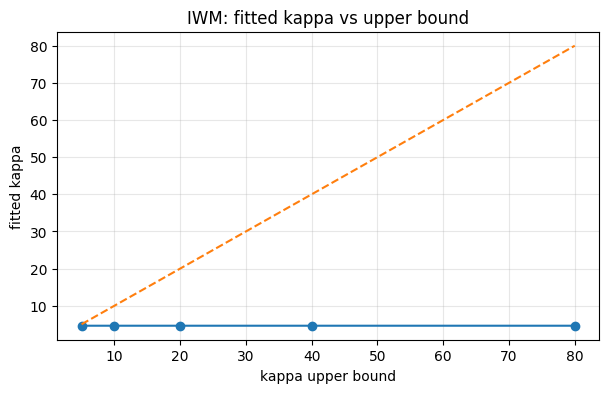

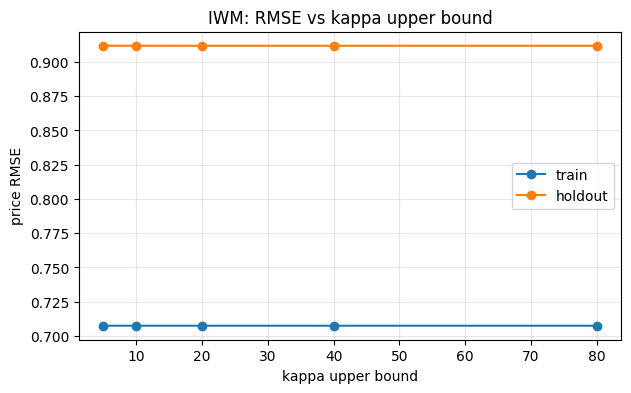

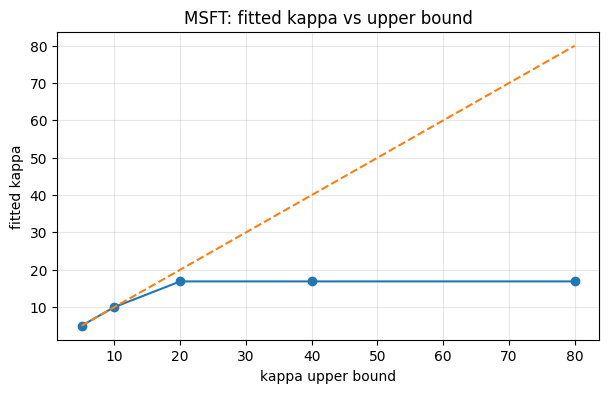

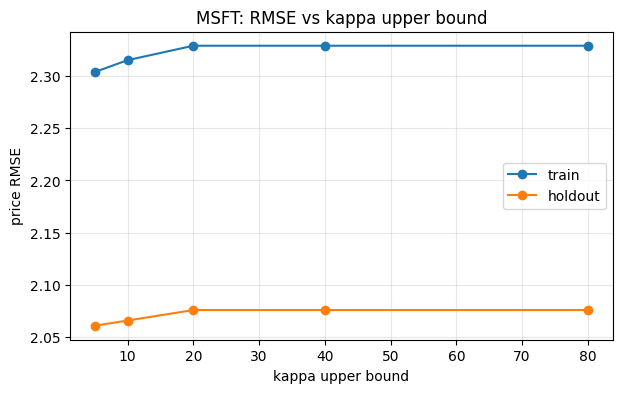

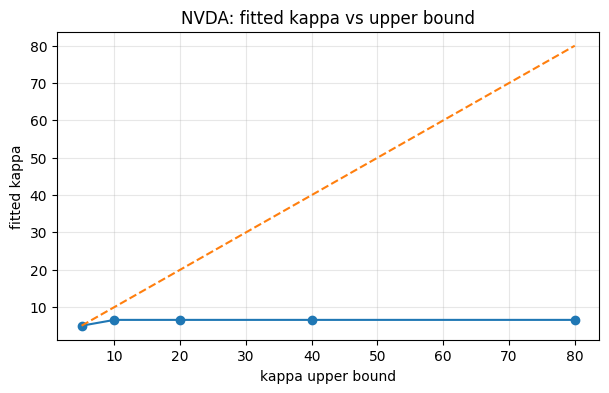

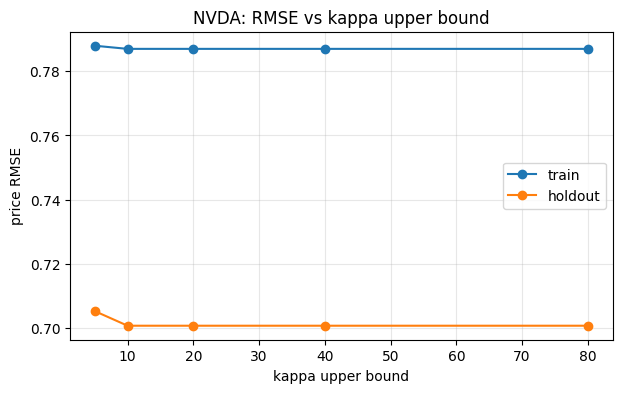

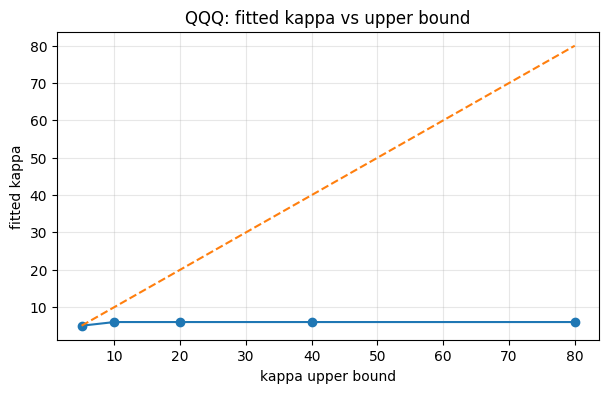

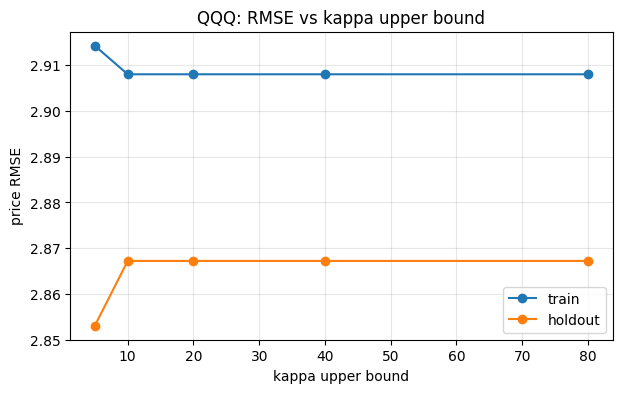

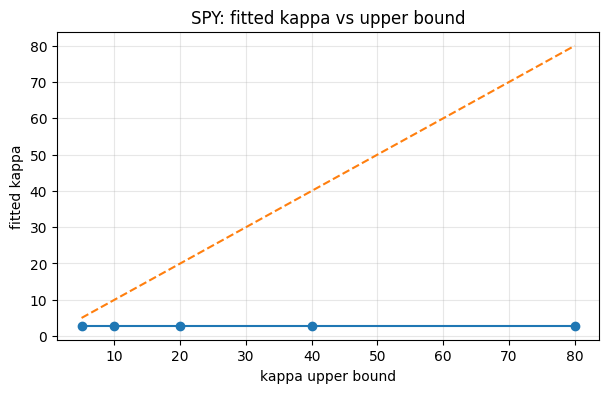

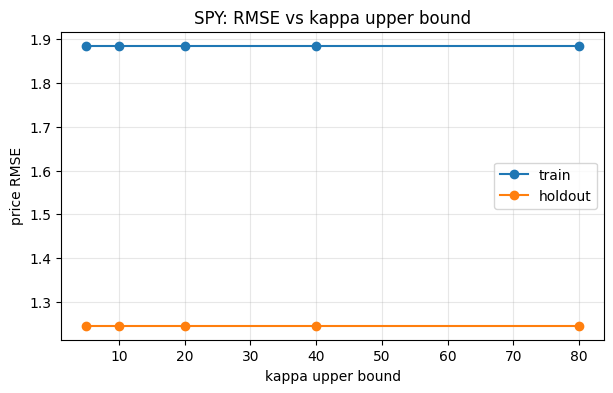

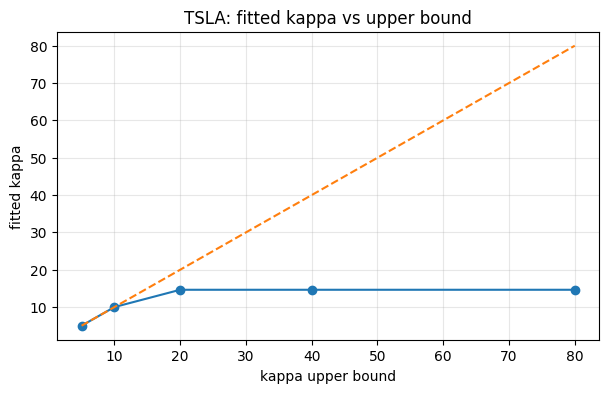

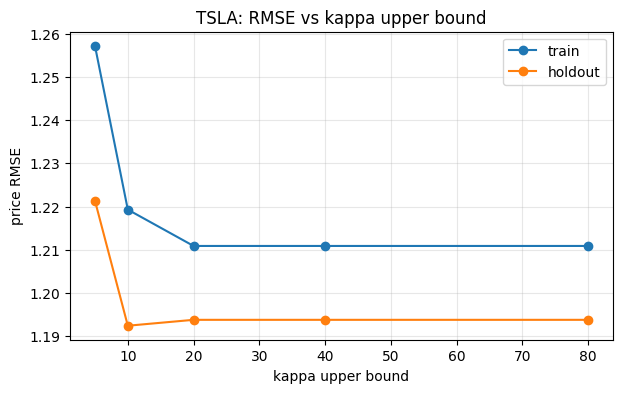

In [10]:
if RUN_KAPPA_BOUND_LADDER and not kappa_ladder_table.empty:
    ok_ladder = kappa_ladder_table.loc[kappa_ladder_table["status"] == "ok"].copy()
    for underlying, group in ok_ladder.groupby("underlying", sort=True):
        group = group.sort_values("kappa_upper")
        plt.figure(figsize=(7, 4))
        plt.plot(group["kappa_upper"], group["kappa"], marker="o")
        plt.plot(group["kappa_upper"], group["kappa_upper"], linestyle="--")
        plt.xlabel("kappa upper bound")
        plt.ylabel("fitted kappa")
        plt.title(f"{underlying}: fitted kappa vs upper bound")
        plt.grid(True, alpha=0.3)
        plt.show()

        plt.figure(figsize=(7, 4))
        plt.plot(group["kappa_upper"], group["train_price_rmse"], marker="o", label="train")
        plt.plot(group["kappa_upper"], group["holdout_price_rmse"], marker="o", label="holdout")
        plt.xlabel("kappa upper bound")
        plt.ylabel("price RMSE")
        plt.title(f"{underlying}: RMSE vs kappa upper bound")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()


## 7. Nested maturity-exclusion test

This fixes the original deterministic study universe, then progressively drops front maturities without replacement.

That makes the test cleaner than a rolling-window test: changes come from removing front maturities, not from admitting new later maturities.

In [11]:
nested_rows: list[dict[str, Any]] = []

if RUN_NESTED_MATURITY_EXCLUSION:
    for _, bundle_row in study_bundles.iterrows():
        bundle_dir = Path(bundle_row["bundle_dir"])
        if bundle_dir in loaded_cache:
            loaded, base_selected, _filter_evidence = loaded_cache[bundle_dir]
        else:
            loaded, base_selected, _filter_evidence = load_selected_bundle(bundle_row)

        base_expiries = tuple(round(float(x) * 365.0, 2) for x in sorted(base_selected["expiry_years"].unique()))

        for min_t_days in NESTED_MIN_T_DAYS:
            subset = base_selected.loc[
                pd.to_numeric(base_selected["expiry_years"], errors="coerce") >= float(min_t_days) / 365.0
            ].copy().reset_index(drop=True)

            nested_rows.append(
                run_one_heston_diagnostic(
                    loaded=loaded,
                    selected_frame=subset,
                    objective_type=PRIMARY_OBJECTIVE_TYPE,
                    bounds=HestonCalibrationBounds(),
                    experiment="nested_maturity_exclusion",
                    extra_meta={
                        "underlying": bundle_row["underlying"],
                        "date": bundle_row["date"],
                        "run_id": bundle_row["run_id"],
                        "bundle_dir": str(bundle_dir),
                        "min_t_days": float(min_t_days),
                        "base_quote_count": int(len(base_selected)),
                        "selected_quotes_after_drop": int(len(subset)),
                        "dropped_quote_count": int(len(base_selected) - len(subset)),
                        "base_expiry_count": int(base_selected["expiry_years"].nunique()),
                        "selected_expiry_count": int(subset["expiry_years"].nunique()) if not subset.empty else 0,
                        "base_expiry_days": base_expiries,
                        "selected_expiry_days": tuple(
                            round(float(x) * 365.0, 2)
                            for x in sorted(subset["expiry_years"].dropna().unique())
                        ),
                    },
                    include_kappa_profile=False,
                )
            )

nested_table = serializable_results_table(nested_rows)
display(nested_table)

cols = [
    "underlying", "min_t_days", "status",
    "base_quote_count", "selected_quotes_after_drop", "dropped_quote_count",
    "base_expiry_count", "selected_expiry_count", "selected_expiry_days",
    "train_price_rmse", "holdout_price_rmse",
    "kappa", "near_kappa_upper", "eta", "rho", "feller_ratio",
    "warning_labels", "message",
]
if not nested_table.empty:
    display(nested_table[[c for c in cols if c in nested_table.columns]])


,status,experiment,objective_type,quote_count,train_quote_count,holdout_quote_count,expiry_count,actual_min_expiry_days,actual_max_expiry_days,success_count,failure_count,best_cost,kappa,vbar,eta,rho,v,feller_ratio,feller_satisfied,near_kappa_upper,any_parameter_near_boundary,eta_high,rho_near_boundary,warning_labels,verdict,train_price_rmse,holdout_price_rmse,train_iv_rmse_bps,holdout_iv_rmse_bps,max_bucket_price_rmse,max_bucket_iv_rmse_bps,underlying,date,run_id,bundle_dir,min_t_days,base_quote_count,selected_quotes_after_drop,dropped_quote_count,base_expiry_count,selected_expiry_count,base_expiry_days,selected_expiry_days
0,ok,nested_maturity_exclusion,price_rmse,900,672,228,11,19.534094,166.534094,8,0,102.164198,4.611541,0.083932,2.026171,-0.274744,0.072128,0.188562,False,False,False,False,False,"(FELLER_WEAK_OR_VIOLATED,)",usable_with_caution,0.707475,0.911795,496.363522,557.296322,2.231418,1097.446997,IWM,2026-06-06,b4a-20260606T111054Z-d64ab9a6,C:\Users\ouwez\Documents\Quant\option-pricing-...,1.0,900,900,0,11,11,"(19.53, 23.53, 25.53, 33.53, 40.53, 47.53, 75....","(19.53, 23.53, 25.53, 33.53, 40.53, 47.53, 75...."
1,ok,nested_maturity_exclusion,price_rmse,900,672,228,11,19.534094,166.534094,8,0,102.164198,4.611541,0.083932,2.026171,-0.274744,0.072128,0.188562,False,False,False,False,False,"(FELLER_WEAK_OR_VIOLATED,)",usable_with_caution,0.707475,0.911795,496.363522,557.296322,2.231418,1097.446997,IWM,2026-06-06,b4a-20260606T111054Z-d64ab9a6,C:\Users\ouwez\Documents\Quant\option-pricing-...,7.0,900,900,0,11,11,"(19.53, 23.53, 25.53, 33.53, 40.53, 47.53, 75....","(19.53, 23.53, 25.53, 33.53, 40.53, 47.53, 75...."
2,ok,nested_maturity_exclusion,price_rmse,900,672,228,11,19.534094,166.534094,8,0,102.164198,4.611541,0.083932,2.026171,-0.274744,0.072128,0.188562,False,False,False,False,False,"(FELLER_WEAK_OR_VIOLATED,)",usable_with_caution,0.707475,0.911795,496.363522,557.296322,2.231418,1097.446997,IWM,2026-06-06,b4a-20260606T111054Z-d64ab9a6,C:\Users\ouwez\Documents\Quant\option-pricing-...,14.0,900,900,0,11,11,"(19.53, 23.53, 25.53, 33.53, 40.53, 47.53, 75....","(19.53, 23.53, 25.53, 33.53, 40.53, 47.53, 75...."
3,ok,nested_maturity_exclusion,price_rmse,635,474,161,8,33.534094,166.534094,8,0,82.882030,2.113661,0.113541,1.650676,-0.239290,0.065827,0.176155,False,False,False,False,False,"(FELLER_WEAK_OR_VIOLATED,)",usable_with_caution,0.752657,0.966086,453.561889,528.196977,2.066549,1030.475257,IWM,2026-06-06,b4a-20260606T111054Z-d64ab9a6,C:\Users\ouwez\Documents\Quant\option-pricing-...,30.0,900,635,265,11,8,"(19.53, 23.53, 25.53, 33.53, 40.53, 47.53, 75....","(33.53, 40.53, 47.53, 75.53, 103.53, 115.53, 1..."
4,ok,nested_maturity_exclusion,price_rmse,392,292,100,6,47.534094,166.534094,8,0,65.943652,1.243461,0.155206,1.605315,-0.176173,0.064654,0.149778,False,False,False,False,False,"(FELLER_WEAK_OR_VIOLATED,)",usable_with_caution,0.851438,1.086853,492.029224,599.979808,1.876011,943.613281,IWM,2026-06-06,b4a-20260606T111054Z-d64ab9a6,C:\Users\ouwez\Documents\Quant\option-pricing-...,45.0,900,392,508,11,6,"(19.53, 23.53, 25.53, 33.53, 40.53, 47.53, 75....","(47.53, 75.53, 103.53, 115.53, 131.53, 166.53)"
5,ok,nested_maturity_exclusion,price_rmse,289,215,74,5,75.534094,166.534094,8,0,59.350979,2.333042,0.125330,2.057766,-0.136359,0.065599,0.138107,False,False,False,False,False,"(FELLER_WEAK_OR_VIOLATED, MULTISTART_DISPERSIO...",usable_with_caution,0.940693,1.162165,534.436492,652.494531,1.768279,883.986529,IWM,2026-06-06,b4a-20260606T111054Z-d64ab9a6,C:\Users\ouwez\Documents\Quant\option-pricing-...,60.0,900,289,611,11,5,"(19.53, 23.53, 25.53, 33.53, 40.53, 47.53, 75....","(75.53, 103.53, 115.53, 131.53, 166.53)"
6,ok,nested_maturity_exclusion,price_rmse,618,463,155,9,19.533717,166.533717,8,0,520.700590,16.871298,0.139409,2.969031,0.135670,0.080498,0.533631,False,False,False,False,False,"(FELLER_WEAK_OR_VIOLATED,)",usable_with_caution,2.329026,2.075947,542.746908,469.942939,3.307018,773.008299,MSFT,2026-06-06,b4a-20260606T11

,underlying,min_t_days,status,base_quote_count,selected_quotes_after_drop,dropped_quote_count,base_expiry_count,selected_expiry_count,selected_expiry_days,train_price_rmse,holdout_price_rmse,kappa,near_kappa_upper,eta,rho,feller_ratio,warning_labels
0,IWM,1.0,ok,900,900,0,11,11,"(19.53, 23.53, 25.53, 33.53, 40.53, 47.53, 75....",0.707475,0.911795,4.611541,False,2.026171,-0.274744,0.188562,"(FELLER_WEAK_OR_VIOLATED,)"
1,IWM,7.0,ok,900,900,0,11,11,"(19.53, 23.53, 25.53, 33.53, 40.53, 47.53, 75....",0.707475,0.911795,4.611541,False,2.026171,-0.274744,0.188562,"(FELLER_WEAK_OR_VIOLATED,)"
2,IWM,14.0,ok,900,900,0,11,11,"(19.53, 23.53, 25.53, 33.53, 40.53, 47.53, 75....",0.707475,0.911795,4.611541,False,2.026171,-0.274744,0.188562,"(FELLER_WEAK_OR_VIOLATED,)"
3,IWM,30.0,ok,900,635,265,11,8,"(33.53, 40.53, 47.53, 75.53, 103.53, 115.53, 1...",0.752657,0.966086,2.113661,False,1.650676,-0.239290,0.176155,"(FELLER_WEAK_OR_VIOLATED,)"
4,IWM,45.0,ok,900,392,508,11,6,"(47.53, 75.53, 103.53, 115.53, 131.53, 166.53)",0.851438,1.086853,1.243461,False,1.605315,-0.176173,0.149778,"(FELLER_WEAK_OR_VIOLATED,)"
5,IWM,60.0,ok,900,289,611,11,5,"(75.53, 103.53, 115.53, 131.53, 166.53)",0.940693,1.162165,2.333042,False,2.057766,-0.136359,0.138107,"(FELLER_WEAK_OR_VIOLATED, MULTISTART_DISPERSIO..."
6,MSFT,1.0,ok,618,618,0,9,9,"(19.53, 25.53, 33.53, 40.53, 47.53, 75.53, 103...",2.329026,2.075947,16.871298,False,2.969031,0.135670,0.533631,"(FELLER_WEAK_OR_VIOLATED,)"
7,MSFT,7.0,ok,618,618,0,9,9,"(19.53, 25.53, 33.53, 40.53, 47.53, 75.53, 103...",2.329026,2.075947,16.871298,False,2.969031,0.135670,0.533631,"(FELLER_WEAK_OR_VIOLATED,)"
8,MSFT,14.0,ok,618,618,0,9,9,"(19.53, 25.53, 33.53, 40.53, 47.53, 75.53, 103...",2.329026,2.075947,16.871298,False,2.969031,0.135670,0.533631,"(FELLER_WEAK_OR_VIOLATED,)"
9,MSFT,30.0,ok,618,538,80,9,7,"(33.53, 40.53, 47.53, 75.53, 103.53, 131.53, 1...",2.435061,2.152817,19.999997,True,3.503579,0.149769,0.448384,"(PARAMETER_NEAR_BOUND, KAPPA_NEAR_UPPER_BOUND,..."


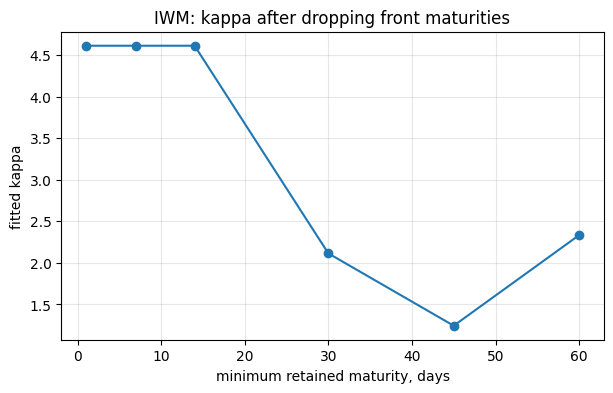

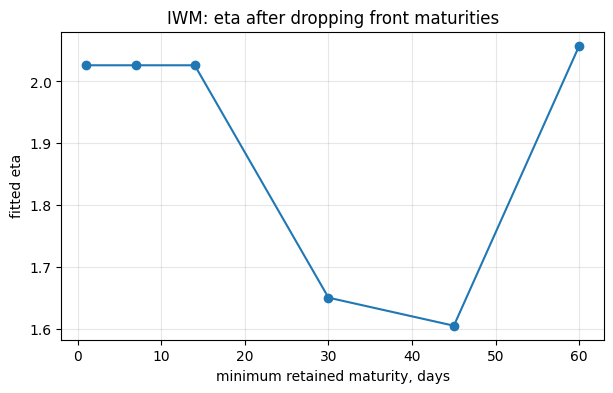

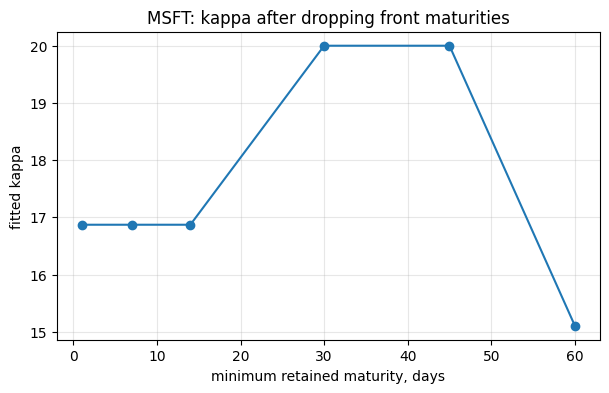

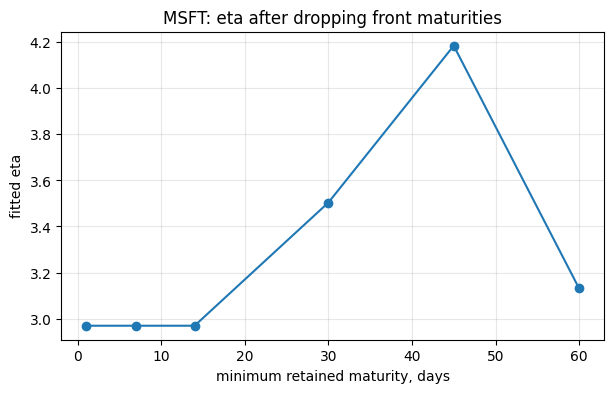

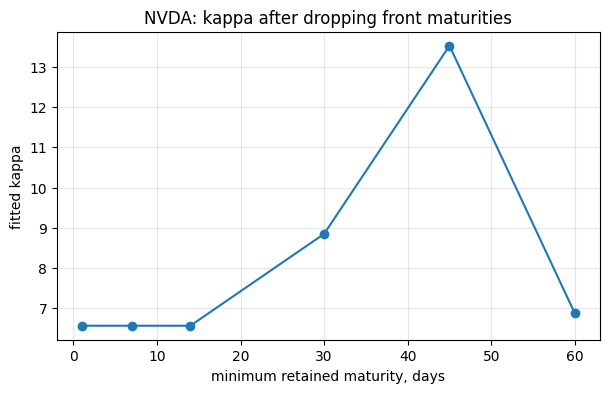

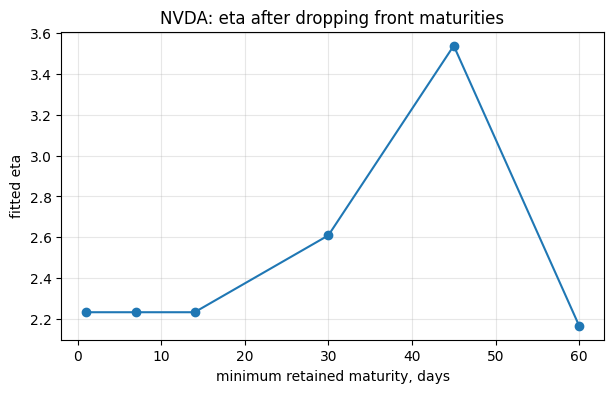

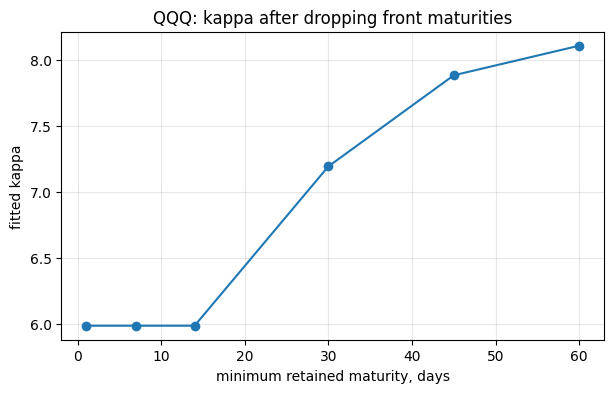

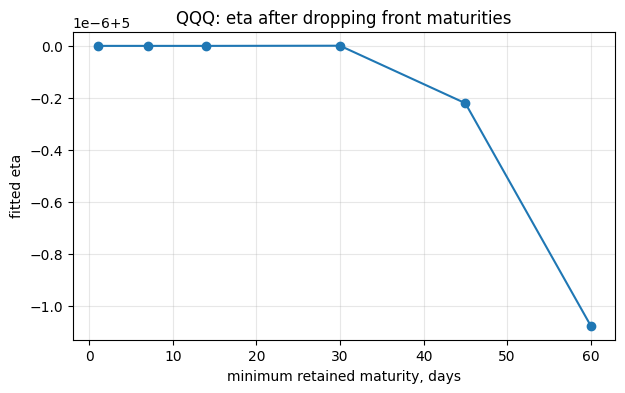

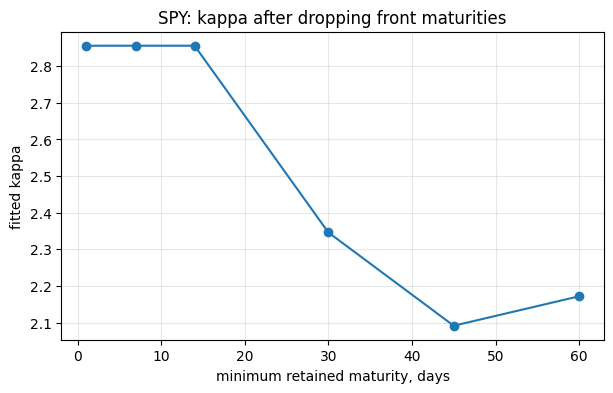

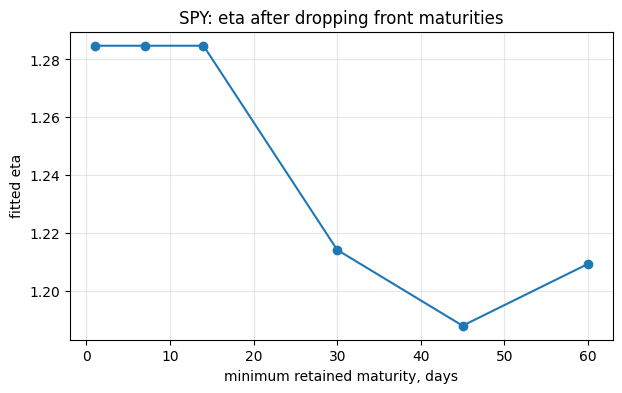

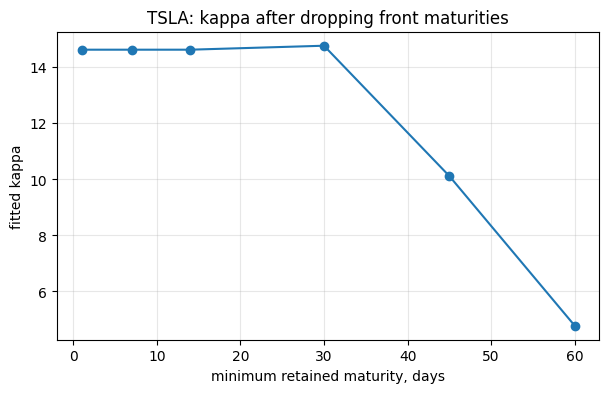

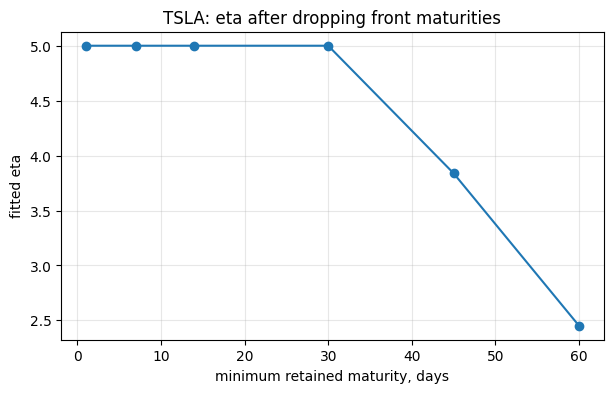

In [12]:
if RUN_NESTED_MATURITY_EXCLUSION and not nested_table.empty:
    ok_nested = nested_table.loc[nested_table["status"] == "ok"].copy()
    for underlying, group in ok_nested.groupby("underlying", sort=True):
        group = group.sort_values("min_t_days")
        plt.figure(figsize=(7, 4))
        plt.plot(group["min_t_days"], group["kappa"], marker="o")
        plt.xlabel("minimum retained maturity, days")
        plt.ylabel("fitted kappa")
        plt.title(f"{underlying}: kappa after dropping front maturities")
        plt.grid(True, alpha=0.3)
        plt.show()

        plt.figure(figsize=(7, 4))
        plt.plot(group["min_t_days"], group["eta"], marker="o")
        plt.xlabel("minimum retained maturity, days")
        plt.ylabel("fitted eta")
        plt.title(f"{underlying}: eta after dropping front maturities")
        plt.grid(True, alpha=0.3)
        plt.show()


## 8. Residual decomposition

Aggregate RMSE can hide where the model misses. This section uses the diagnostic `residual_buckets` table.

In [13]:
def collect_residual_bucket_rows(results: list[dict[str, Any]]) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    for row in results:
        report = row.get("report")
        if row.get("status") != "ok" or report is None:
            continue
        buckets = report.tables.get("residual_buckets", pd.DataFrame()).copy()
        if buckets.empty:
            continue
        for _, b in buckets.iterrows():
            rows.append(
                {
                    "underlying": row.get("underlying"),
                    "date": row.get("date"),
                    "run_id": row.get("run_id"),
                    "experiment": row.get("experiment"),
                    "objective_type": row.get("objective_type"),
                    "bucket_type": b.get("bucket_type"),
                    "bucket": b.get("bucket"),
                    "n_quotes": b.get("n_quotes"),
                    "price_rmse": b.get("price_rmse"),
                    "price_mae": b.get("price_mae"),
                    "price_max_abs": b.get("price_max_abs"),
                    "iv_rmse_bps": b.get("iv_rmse_bps"),
                    "iv_mae_bps": b.get("iv_mae_bps"),
                    "iv_max_abs_bps": b.get("iv_max_abs_bps"),
                    "notes": b.get("notes"),
                }
            )
    return pd.DataFrame(rows)


if RUN_ERROR_DECOMPOSITION:
    residual_bucket_table = collect_residual_bucket_rows([
        row for row in baseline_rows
        if row.get("experiment") == "baseline_objective_sweep"
        and row.get("objective_type") == PRIMARY_OBJECTIVE_TYPE
    ])

    if residual_bucket_table.empty:
        print("No residual bucket rows available.")
    else:
        worst_price_buckets = residual_bucket_table.sort_values(
            ["underlying", "price_rmse"],
            ascending=[True, False],
        ).groupby("underlying", group_keys=False).head(8)

        worst_iv_buckets = residual_bucket_table.sort_values(
            ["underlying", "iv_rmse_bps"],
            ascending=[True, False],
        ).groupby("underlying", group_keys=False).head(8)

        print("Worst price residual buckets by underlying:")
        display(worst_price_buckets)

        print("Worst IV residual buckets by underlying:")
        display(worst_iv_buckets)
else:
    residual_bucket_table = pd.DataFrame()


Worst price residual buckets by underlying:


,underlying,date,run_id,experiment,objective_type,bucket_type,bucket,n_quotes,price_rmse,price_mae,price_max_abs,iv_rmse_bps,iv_mae_bps,iv_max_abs_bps,notes
15,IWM,2026-06-06,b4a-20260606T111054Z-d64ab9a6,baseline_objective_sweep,price_rmse,log_moneyness,y>0.10,75,2.231418,1.817687,5.144760,1097.446997,976.575219,2193.614908,
10,IWM,2026-06-06,b4a-20260606T111054Z-d64ab9a6,baseline_objective_sweep,price_rmse,expiry,0.4562577926,53,1.787229,1.177676,5.037297,747.022863,562.377744,1860.797568,
9,IWM,2026-06-06,b4a-20260606T111054Z-d64ab9a6,baseline_objective_sweep,price_rmse,expiry,0.3603673817,44,1.703836,1.058327,5.144760,817.683405,565.338789,2193.614908,
21,IWM,2026-06-06,b4a-20260606T111054Z-d64ab9a6,baseline_objective_sweep,price_rmse,spread,spread_high,300,1.240860,0.813901,5.144760,843.806976,617.915473,3652.356596,
18,IWM,2026-06-06,b4a-20260606T111054Z-d64ab9a6,baseline_objective_sweep,price_rmse,vega,vega_high,300,1.134313,0.608003,5.144760,548.111715,357.891662,2193.614908,
7,IWM,2026-06-06,b4a-20260606T111054Z-d64ab9a6,baseline_objective_sweep,price_rmse,expiry,0.2836550529,53,0.931268,0.634576,2.613012,664.760512,473.280540,1629.621666,
16,IWM,2026-06-06,b4a-20260606T111054Z-d64ab9a6,baseline_objective_sweep,price_rmse,option_right,put,468,0.917228,0.436002,5.144760,456.990232,254.663311,2193.614908,
8,IWM,2026-06-06,b4a-20260606T111054Z-d64ab9a6,baseline_objective_sweep,price_rmse,expiry,0.3165317652,92,0.763817,0.492922,2.783740,572.336527,386.656307,1498.788328,
36,MSFT,2026-06-06,b4a-20260606T111126Z-0d4d8cc7,baseline_objective_sweep,price_rmse,log_moneyness,y>0.10,194,3.307018,2.481476,9.831308,433.364472,276.873681,1567.974265,
43,MSFT,2026-06-06,b4a-20260606T111126Z-0d4d8cc7,baseline_objective_sweep,price_rmse,spread,spread_high,206,3.132604,2.447402,9.831308,773.008299,651.203259,1912.185436,


Worst IV residual buckets by underlying:


,underlying,date,run_id,experiment,objective_type,bucket_type,bucket,n_quotes,price_rmse,price_mae,price_max_abs,iv_rmse_bps,iv_mae_bps,iv_max_abs_bps,notes
15,IWM,2026-06-06,b4a-20260606T111054Z-d64ab9a6,baseline_objective_sweep,price_rmse,log_moneyness,y>0.10,75,2.231418,1.817687,5.144760,1097.446997,976.575219,2193.614908,
21,IWM,2026-06-06,b4a-20260606T111054Z-d64ab9a6,baseline_objective_sweep,price_rmse,spread,spread_high,300,1.240860,0.813901,5.144760,843.806976,617.915473,3652.356596,
9,IWM,2026-06-06,b4a-20260606T111054Z-d64ab9a6,baseline_objective_sweep,price_rmse,expiry,0.3603673817,44,1.703836,1.058327,5.144760,817.683405,565.338789,2193.614908,
14,IWM,2026-06-06,b4a-20260606T111054Z-d64ab9a6,baseline_objective_sweep,price_rmse,log_moneyness,y<=-0.10,177,0.644585,0.469794,2.074051,796.552837,480.306876,3652.356596,
10,IWM,2026-06-06,b4a-20260606T111054Z-d64ab9a6,baseline_objective_sweep,price_rmse,expiry,0.4562577926,53,1.787229,1.177676,5.037297,747.022863,562.377744,1860.797568,
1,IWM,2026-06-06,b4a-20260606T111054Z-d64ab9a6,baseline_objective_sweep,price_rmse,expiry,0.0644769707,102,0.570698,0.354562,2.074051,742.254039,396.352140,3652.356596,
7,IWM,2026-06-06,b4a-20260606T111054Z-d64ab9a6,baseline_objective_sweep,price_rmse,expiry,0.2836550529,53,0.931268,0.634576,2.613012,664.760512,473.280540,1629.621666,
19,IWM,2026-06-06,b4a-20260606T111054Z-d64ab9a6,baseline_objective_sweep,price_rmse,vega,vega_low,300,0.570683,0.418646,2.074051,649.420117,395.489881,3652.356596,
43,MSFT,2026-06-06,b4a-20260606T111126Z-0d4d8cc7,baseline_objective_sweep,price_rmse,spread,spread_high,206,3.132604,2.447402,9.831308,773.008299,651.203259,1912.185436,
26,MSFT,2026-06-06,b4a-20260606T111126Z-0d4d8cc7,baseline_objective_sweep,price_rmse,expiry,0.0918731978,47,1.367289,1.250398,2.754687,637.291795,471.051586,1685.642984,


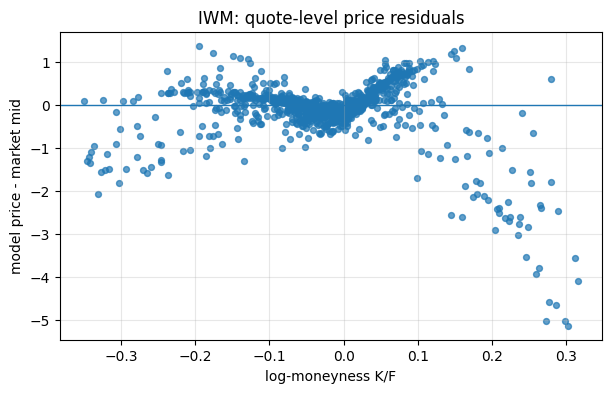

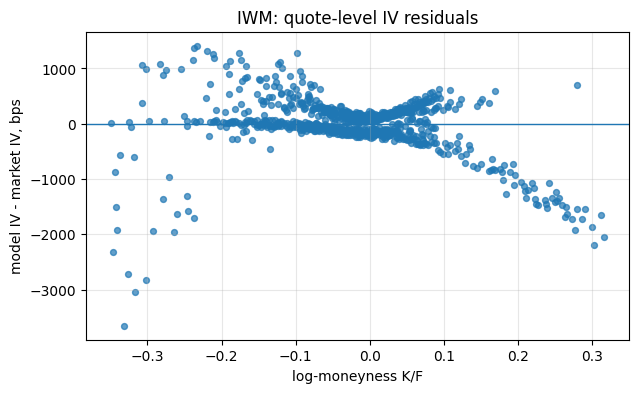

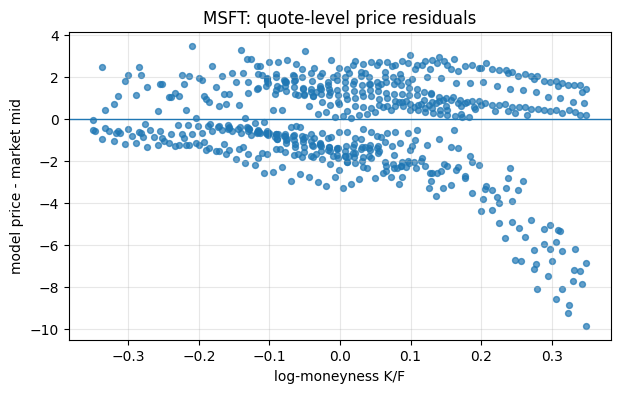

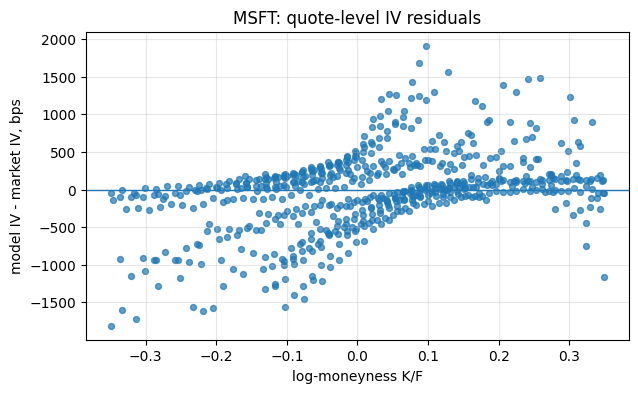

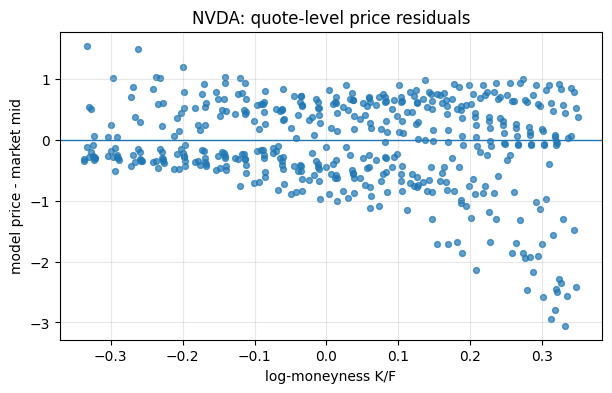

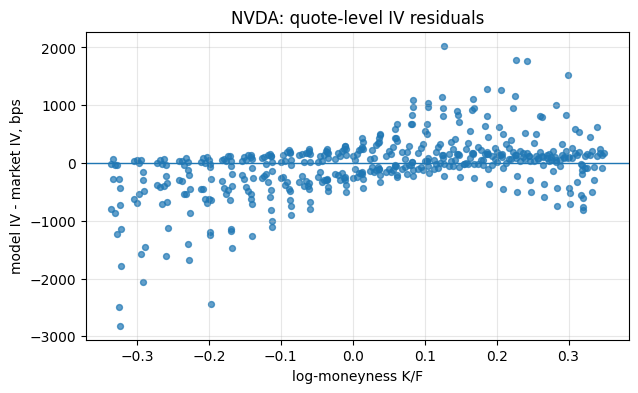

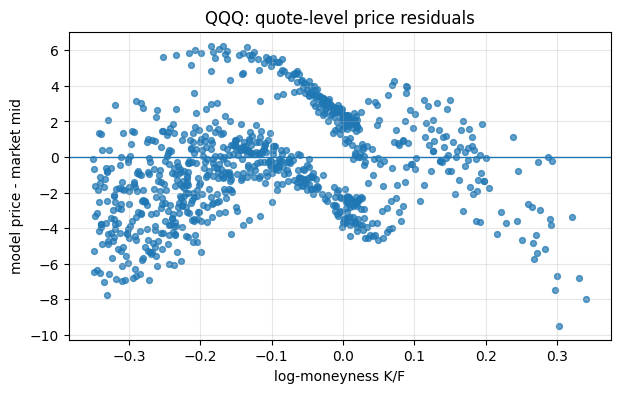

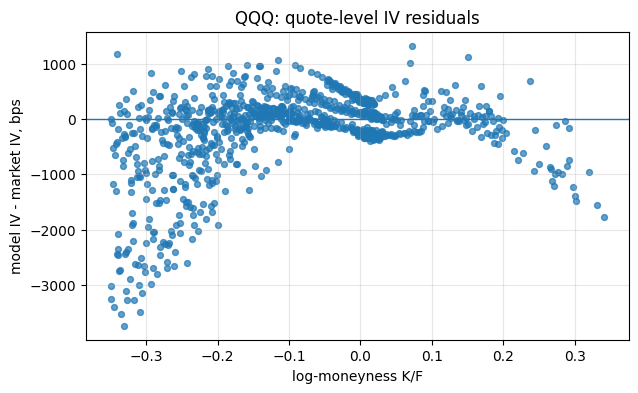

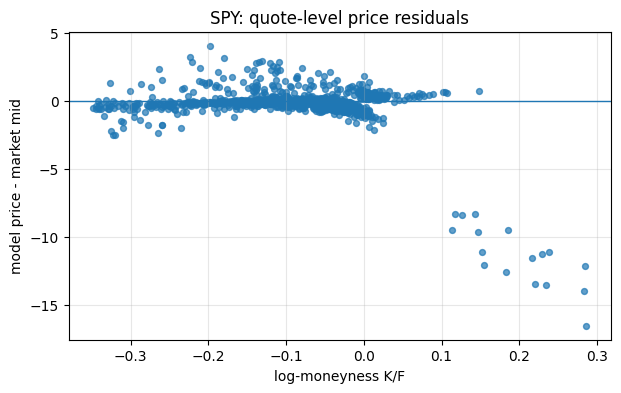

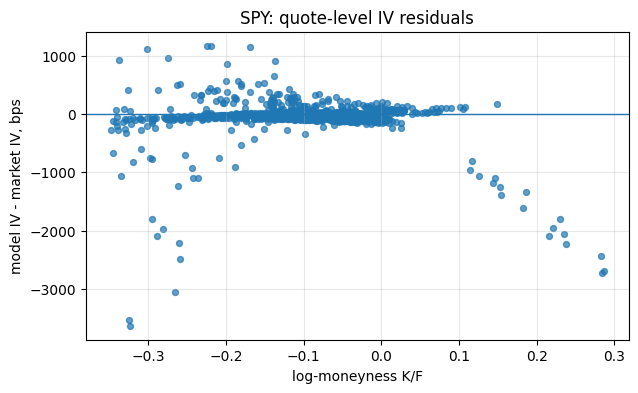

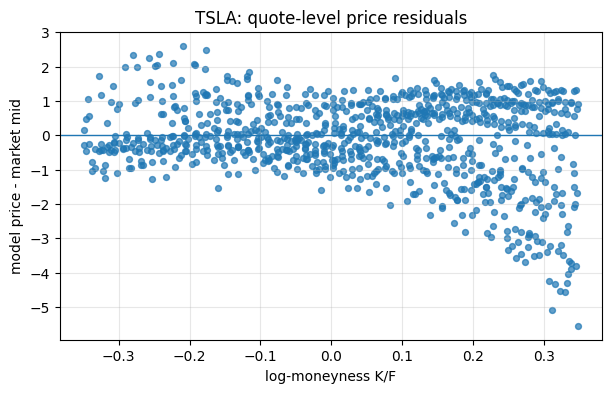

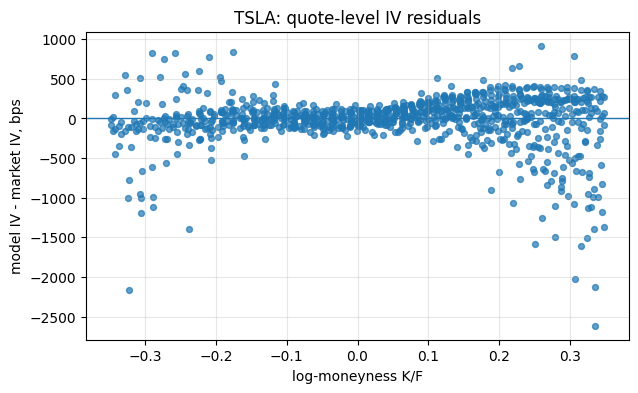

In [14]:
def collect_quote_level_residuals(results: list[dict[str, Any]]) -> pd.DataFrame:
    rows: list[pd.DataFrame] = []
    for row in results:
        report = row.get("report")
        if row.get("status") != "ok" or report is None:
            continue
        residuals = report.tables.get("residuals", pd.DataFrame()).copy()
        if residuals.empty:
            continue
        residuals["underlying"] = row.get("underlying")
        residuals["date"] = row.get("date")
        residuals["objective_type"] = row.get("objective_type")
        residuals["experiment"] = row.get("experiment")
        rows.append(residuals)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


if RUN_ERROR_DECOMPOSITION:
    quote_residuals = collect_quote_level_residuals([
        row for row in baseline_rows
        if row.get("experiment") == "baseline_objective_sweep"
        and row.get("objective_type") == PRIMARY_OBJECTIVE_TYPE
    ])

    if not quote_residuals.empty:
        for underlying, group in quote_residuals.groupby("underlying", sort=True):
            plt.figure(figsize=(7, 4))
            plt.scatter(group["log_moneyness"], group["price_residual"], s=18, alpha=0.7)
            plt.axhline(0.0, linewidth=1)
            plt.xlabel("log-moneyness K/F")
            plt.ylabel("model price - market mid")
            plt.title(f"{underlying}: quote-level price residuals")
            plt.grid(True, alpha=0.3)
            plt.show()

            finite_iv = group[np.isfinite(pd.to_numeric(group["iv_residual_bps"], errors="coerce"))]
            if not finite_iv.empty:
                plt.figure(figsize=(7, 4))
                plt.scatter(finite_iv["log_moneyness"], finite_iv["iv_residual_bps"], s=18, alpha=0.7)
                plt.axhline(0.0, linewidth=1)
                plt.xlabel("log-moneyness K/F")
                plt.ylabel("model IV - market IV, bps")
                plt.title(f"{underlying}: quote-level IV residuals")
                plt.grid(True, alpha=0.3)
                plt.show()
else:
    quote_residuals = pd.DataFrame()


## 9. Objective-slice and kappa-profile review

The diagnostics report includes local objective slices and kappa profiles. These help distinguish poor fit from weak parameter identification.

,kappa,profile_mode,success,cost,delta_cost_vs_base,nfev,status,message,fitted_kappa,fitted_vbar,fitted_eta,fitted_rho,fitted_v,price_rmse,price_mae,price_max_abs,iv_rmse_bps,iv_mae_bps,iv_max_abs_bps,underlying,date,objective_type,experiment
0,5.0,hold_other_params_fixed,True,265.286054,2.335083,0,None,held other parameters fixed,4.611541,0.083932,2.026171,-0.274744,0.072128,0.767805,0.435631,5.165298,513.876232,310.527381,3660.136408,IWM,2026-06-06,price_rmse,baseline_objective_sweep
1,10.0,hold_other_params_fixed,True,424.140740,161.189769,0,None,held other parameters fixed,4.611541,0.083932,2.026171,-0.274744,0.072128,0.970842,0.662500,5.336602,537.929700,324.626276,3763.405099,IWM,2026-06-06,price_rmse,baseline_objective_sweep
2,20.0,hold_other_params_fixed,True,749.407504,486.456532,0,None,held other parameters fixed,4.611541,0.083932,2.026171,-0.274744,0.072128,1.290484,0.952354,5.422087,579.597189,383.623345,3952.498850,IWM,2026-06-06,price_rmse,baseline_objective_sweep
3,5.0,hold_other_params_fixed,True,4231.239883,2641.509407,0,None,held other parameters fixed,16.871298,0.139409,2.969031,0.135670,0.080498,3.700450,2.807046,9.399045,652.518543,492.385846,1707.340264,MSFT,2026-06-06,price_rmse,baseline_objective_sweep
4,10.0,hold_other_params_fixed,True,1932.779863,343.049387,0,None,held other parameters fixed,16.871298,0.139409,2.969031,0.135670,0.080498,2.500990,1.863353,9.593708,553.080069,385.781912,1788.662090,MSFT,2026-06-06,price_rmse,baseline_objective_sweep
5,20.0,hold_other_params_fixed,True,1641.333647,51.603171,0,None,held other parameters fixed,16.871298,0.139409,2.969031,0.135670,0.080498,2.304725,1.737812,9.919307,524.823229,367.687473,1953.337052,MSFT,2026-06-06,price_rmse,baseline_objective_sweep
6,5.0,hold_other_params_fixed,True,173.079582,35.303191,0,None,held other parameters fixed,6.563889,0.268575,2.233955,-0.017815,0.170102,0.858201,0.646137,3.074851,530.557172,346.496052,2811.096024,NVDA,2026-06-06,price_rmse,baseline_objective_sweep
7,10.0,hold_other_params_fixed,True,199.113759,61.337368,0,None,held other parameters fixed,6.563889,0.268575,2.233955,-0.017815,0.170102,0.920485,0.710604,3.006748,549.117167,386.128683,2822.330665,NVDA,2026-06-06,price_rmse,baseline_objective_sweep
8,20.0,hold_other_params_fixed,True,455.394251,317.617860,0,None,held other parameters fixed,6.563889,0.268575,2.233955,-0.017815,0.170102,1.392066,1.129058,3.209201,634.941928,497.753369,2823.424234,NVDA,2026-06-06,price_rmse,baseline_objective_sweep
9,5.0,hold_other_params_fixed,True,3937.417609,158.451898,0,None,held other parameters fixed,5.986008,0.146717,5.000000,-0.643321,0.142440,2.958009,2.394590,9.422368,805.676273,497.318962,3701.229360,QQQ,2026-06-06,price_rmse,baseline_objective_sweep


,slice_name,parameter_x,parameter_y,grid_i,grid_j,value_x,value_y,fitted_x,fitted_y,cost,delta_cost,note,underlying,date,objective_type,experiment
0,kappa_vs_vbar,kappa,vbar,0,0,3.458656,0.053932,4.611541,0.083932,586.401994,323.451022,LIMITATION: Objective slices are local constra...,IWM,2026-06-06,price_rmse,baseline_objective_sweep
1,kappa_vs_vbar,kappa,vbar,0,1,3.458656,0.083932,4.611541,0.083932,279.322164,16.371193,LIMITATION: Objective slices are local constra...,IWM,2026-06-06,price_rmse,baseline_objective_sweep
2,kappa_vs_vbar,kappa,vbar,0,2,3.458656,0.113932,4.611541,0.083932,303.718726,40.767754,LIMITATION: Objective slices are local constra...,IWM,2026-06-06,price_rmse,baseline_objective_sweep
3,kappa_vs_vbar,kappa,vbar,1,0,4.611541,0.053932,4.611541,0.083932,547.660802,284.709830,LIMITATION: Objective slices are local constra...,IWM,2026-06-06,price_rmse,baseline_objective_sweep
4,kappa_vs_vbar,kappa,vbar,1,1,4.611541,0.083932,4.611541,0.083932,262.950971,0.000000,LIMITATION: Objective slices are local constra...,IWM,2026-06-06,price_rmse,baseline_objective_sweep
5,kappa_vs_vbar,kappa,vbar,1,2,4.611541,0.113932,4.611541,0.083932,453.275617,190.324646,LIMITATION: Objective slices are local constra...,IWM,2026-06-06,price_rmse,baseline_objective_sweep
6,kappa_vs_vbar,kappa,vbar,2,0,5.764427,0.053932,4.611541,0.083932,521.757711,258.806740,LIMITATION: Objective slices are local constra...,IWM,2026-06-06,price_rmse,baseline_objective_sweep
7,kappa_vs_vbar,kappa,vbar,2,1,5.764427,0.083932,4.611541,0.083932,277.619585,14.668613,LIMITATION: Objective slices are local constra...,IWM,2026-06-06,price_rmse,baseline_objective_sweep
8,kappa_vs_vbar,kappa,vbar,2,2,5.764427,0.113932,4.611541,0.083932,643.133476,380.182504,LIMITATION: Objective slices are local constra...,IWM,2026-06-06,price_rmse,baseline_objective_sweep
9,eta_vs_rho,eta,rho,0,0,1.519628,-0.524744,2.026171,-0.274744,426.861261,163.910290,LIMITATION: Objective slices are local constra...,IWM,2026-06-06,price_rmse,baseline_objective_sweep


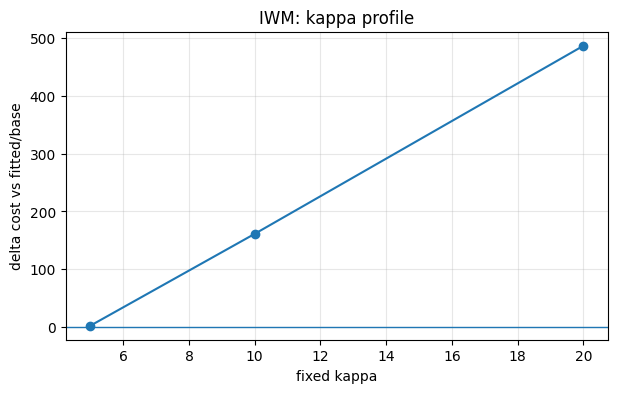

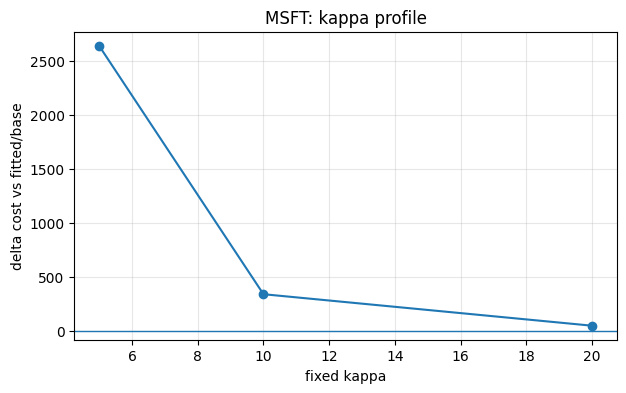

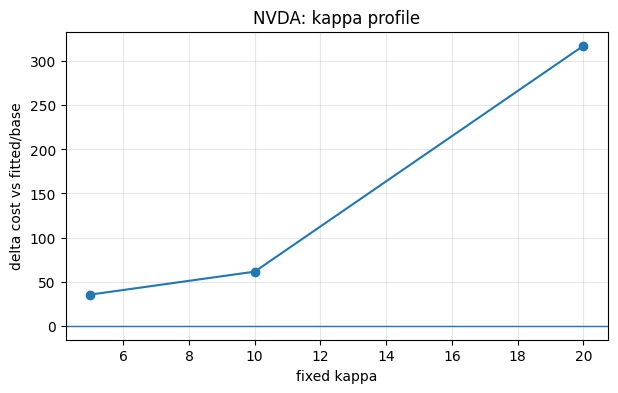

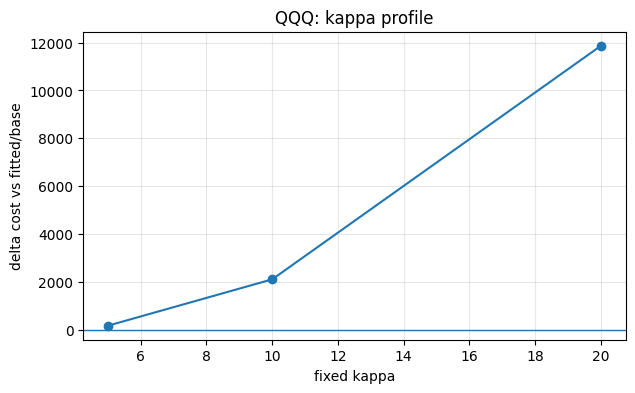

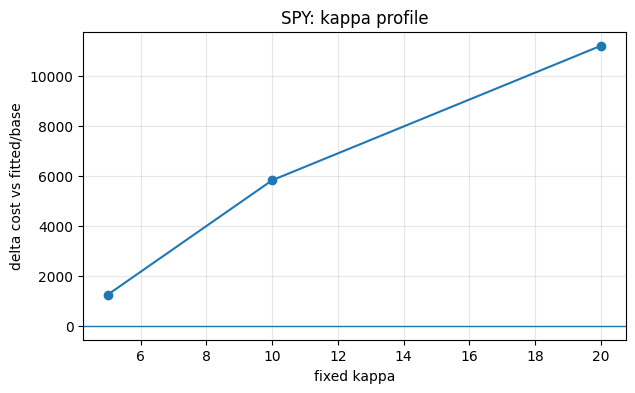

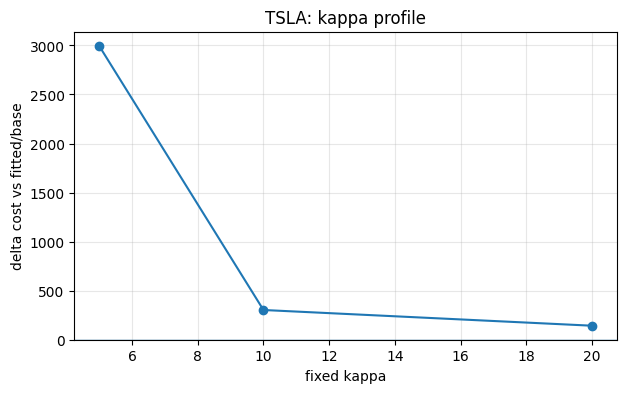

In [15]:
def collect_kappa_profiles(results: list[dict[str, Any]]) -> pd.DataFrame:
    rows: list[pd.DataFrame] = []
    for row in results:
        report = row.get("report")
        if row.get("status") != "ok" or report is None:
            continue
        profile = report.tables.get("kappa_profile", pd.DataFrame()).copy()
        if profile.empty:
            continue
        profile["underlying"] = row.get("underlying")
        profile["date"] = row.get("date")
        profile["objective_type"] = row.get("objective_type")
        profile["experiment"] = row.get("experiment")
        profile["fitted_kappa"] = row.get("kappa")
        rows.append(profile)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


def collect_objective_slices(results: list[dict[str, Any]]) -> pd.DataFrame:
    rows: list[pd.DataFrame] = []
    for row in results:
        report = row.get("report")
        if row.get("status") != "ok" or report is None:
            continue
        slices = report.tables.get("objective_slices", pd.DataFrame()).copy()
        if slices.empty:
            continue
        slices["underlying"] = row.get("underlying")
        slices["date"] = row.get("date")
        slices["objective_type"] = row.get("objective_type")
        slices["experiment"] = row.get("experiment")
        rows.append(slices)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


kappa_profile_table = collect_kappa_profiles([
    row for row in baseline_rows
    if row.get("objective_type") == PRIMARY_OBJECTIVE_TYPE
])
objective_slice_table = collect_objective_slices([
    row for row in baseline_rows
    if row.get("objective_type") == PRIMARY_OBJECTIVE_TYPE
])

display(kappa_profile_table)
display(objective_slice_table.head(30))

if not kappa_profile_table.empty:
    for underlying, group in kappa_profile_table.groupby("underlying", sort=True):
        group = group.sort_values("kappa")
        plt.figure(figsize=(7, 4))
        plt.plot(group["kappa"], group["delta_cost_vs_base"], marker="o")
        plt.axhline(0.0, linewidth=1)
        plt.xlabel("fixed kappa")
        plt.ylabel("delta cost vs fitted/base")
        plt.title(f"{underlying}: kappa profile")
        plt.grid(True, alpha=0.3)
        plt.show()


## 10. Failure morphology

This compresses the diagnostics into human-readable categories for the future limitations doc.

In [16]:
def _contains_label(labels: Any, needle: str) -> bool:
    if labels is None:
        return False
    if isinstance(labels, str):
        return needle in labels
    try:
        return needle in set(labels)
    except TypeError:
        return False


def classify_failure_morphology(row: pd.Series) -> str:
    if row.get("status") != "ok":
        return "calibration_failed_or_skipped"

    labels = row.get("warning_labels", ())
    flags: list[str] = []
    if bool(row.get("near_kappa_upper")) or _contains_label(labels, "KAPPA_NEAR_UPPER_BOUND"):
        flags.append("kappa_boundary_pressure")
    if bool(row.get("eta_high")) or _contains_label(labels, "ETA_HIGH"):
        flags.append("high_vol_of_vol_pressure")
    feller = row.get("feller_ratio")
    if feller is not None and pd.notna(feller) and float(feller) < 1.0:
        flags.append("weak_or_violated_feller")
    if _contains_label(labels, "KAPPA_WEAKLY_IDENTIFIED"):
        flags.append("kappa_weakly_identified")
    if _contains_label(labels, "MULTISTART_DISPERSION_HIGH"):
        flags.append("multistart_instability")
    if _contains_label(labels, "HOLDOUT_WEAK"):
        flags.append("holdout_degradation")
    if bool(row.get("rho_near_boundary")) or _contains_label(labels, "RHO_NEAR_BOUND"):
        flags.append("rho_boundary_pressure")
    if not flags:
        return "no_major_heston_warning"
    return "+".join(flags)


baseline_morphology = baseline_table.copy()
if not baseline_morphology.empty:
    baseline_morphology["failure_morphology"] = baseline_morphology.apply(classify_failure_morphology, axis=1)

cols = [
    "underlying", "date", "objective_type", "status", "verdict",
    "failure_morphology", "train_price_rmse", "holdout_price_rmse",
    "kappa", "eta", "rho", "feller_ratio", "warning_labels", "message",
]
display(baseline_morphology[[c for c in cols if c in baseline_morphology.columns]])

if not baseline_morphology.empty:
    morphology_counts = (
        baseline_morphology
        .groupby(["underlying", "failure_morphology"], dropna=False)
        .size()
        .reset_index(name="count")
        .sort_values(["underlying", "count"], ascending=[True, False])
    )
    display(morphology_counts)


,underlying,date,objective_type,status,verdict,failure_morphology,train_price_rmse,holdout_price_rmse,kappa,eta,rho,feller_ratio,warning_labels
0,IWM,2026-06-06,price_rmse,ok,usable_with_caution,weak_or_violated_feller,0.707475,0.911795,4.611541,2.026171,-0.274744,0.188562,"(FELLER_WEAK_OR_VIOLATED,)"
1,IWM,2026-06-06,vega_scaled_price,ok,usable_with_caution,weak_or_violated_feller,0.837727,1.103019,16.423321,2.555019,-0.445941,0.325295,"(FELLER_WEAK_OR_VIOLATED,)"
2,IWM,2026-06-06,bid_ask_normalized,ok,usable_with_caution,weak_or_violated_feller,0.888838,1.157132,11.174985,1.601445,-0.533627,0.552372,"(FELLER_WEAK_OR_VIOLATED,)"
3,MSFT,2026-06-06,price_rmse,ok,usable_with_caution,weak_or_violated_feller,2.329026,2.075947,16.871298,2.969031,0.135670,0.533631,"(FELLER_WEAK_OR_VIOLATED,)"
4,MSFT,2026-06-06,vega_scaled_price,ok,usable_with_caution,weak_or_violated_feller,2.300169,2.154681,4.924778,2.590773,0.201796,0.257520,"(FELLER_WEAK_OR_VIOLATED,)"
5,MSFT,2026-06-06,bid_ask_normalized,ok,diagnostic_only,kappa_boundary_pressure+high_vol_of_vol_pressu...,2.705466,2.417337,20.000000,4.015765,-0.098653,0.345410,"(PARAMETER_NEAR_BOUND, KAPPA_NEAR_UPPER_BOUND,..."
6,NVDA,2026-06-06,price_rmse,ok,usable_with_caution,weak_or_violated_feller,0.786975,0.700687,6.563889,2.233955,-0.017815,0.706492,"(FELLER_WEAK_OR_VIOLATED,)"
7,NVDA,2026-06-06,vega_scaled_price,ok,diagnostic_only,kappa_boundary_pressure+high_vol_of_vol_pressu...,0.823433,0.740444,20.000000,4.691345,-0.070189,0.428179,"(PARAMETER_NEAR_BOUND, KAPPA_NEAR_UPPER_BOUND,..."
8,NVDA,2026-06-06,bid_ask_normalized,ok,diagnostic_only,kappa_boundary_pressure+high_vol_of_vol_pressu...,0.933665,0.887458,20.000000,4.207322,-0.181613,0.538049,"(PARAMETER_NEAR_BOUND, KAPPA_NEAR_UPPER_BOUND,..."
9,QQQ,2026-06-06,price_rmse,ok,usable_with_caution,high_vol_of_vol_pressure+weak_or_violated_feller,2.908033,2.867202,5.986008,5.000000,-0.643321,0.070260,"(PARAMETER_NEAR_BOUND, ETA_HIGH, FELLER_WEAK_O..."


,underlying,failure_morphology,count
0,IWM,weak_or_violated_feller,3
2,MSFT,weak_or_violated_feller,2
1,MSFT,kappa_boundary_pressure+high_vol_of_vol_pressu...,1
3,NVDA,kappa_boundary_pressure+high_vol_of_vol_pressu...,1
4,NVDA,kappa_boundary_pressure+high_vol_of_vol_pressu...,1
5,NVDA,weak_or_violated_feller,1
6,QQQ,high_vol_of_vol_pressure+weak_or_violated_feller,3
7,SPY,weak_or_violated_feller,2
8,SPY,weak_or_violated_feller+multistart_instability,1
9,TSLA,high_vol_of_vol_pressure+weak_or_violated_feller,3


## 11. Cross-test interpretation

This combines the baseline, kappa ladder, and maturity exclusion evidence into a per-underlying interpretation.

In [17]:
def summarize_underlying_evidence(
    underlying: str,
    baseline: pd.DataFrame,
    ladder: pd.DataFrame,
    nested: pd.DataFrame,
) -> dict[str, Any]:
    b = baseline.loc[(baseline["underlying"] == underlying) & (baseline["status"] == "ok")].copy()
    ladder_ok = ladder.loc[(ladder["underlying"] == underlying) & (ladder["status"] == "ok")].copy() if not ladder.empty else pd.DataFrame()
    n = nested.loc[(nested["underlying"] == underlying) & (nested["status"] == "ok")].copy() if not nested.empty else pd.DataFrame()

    primary = b.loc[b["objective_type"] == PRIMARY_OBJECTIVE_TYPE]
    if primary.empty and not b.empty:
        primary = b.head(1)

    baseline_row = primary.iloc[0].to_dict() if not primary.empty else {}
    objective_warning_count = int(sum(bool(labels) for labels in b.get("warning_labels", pd.Series(dtype=object)))) if not b.empty else 0

    ladder_hit_rate = None
    ladder_chases_bound = None
    if not ladder_ok.empty and "near_kappa_upper" in ladder_ok.columns:
        ladder_hit_rate = float(ladder_ok["near_kappa_upper"].fillna(False).mean())
        ladder_chases_bound = ladder_hit_rate >= 0.5

    nested_persistent_kappa = None
    nested_persistent_eta = None
    nested_thins_out = None
    if not n.empty:
        post_30 = n.loc[pd.to_numeric(n["min_t_days"], errors="coerce") >= 30.0]
        if not post_30.empty:
            nested_persistent_kappa = bool(post_30["near_kappa_upper"].fillna(False).any())
            nested_persistent_eta = bool(pd.to_numeric(post_30["eta"], errors="coerce").ge(ETA_HIGH_THRESHOLD).any())
            nested_thins_out = bool(pd.to_numeric(post_30["selected_expiry_count"], errors="coerce").min() < MIN_EXPIRIES)

    notes: list[str] = []
    morphology = classify_failure_morphology(pd.Series(baseline_row)) if baseline_row else "no_successful_baseline"

    if ladder_chases_bound:
        notes.append("kappa remains sensitive to the calibration bound ladder")
    if nested_persistent_kappa:
        notes.append("kappa pressure persists after dropping front maturities")
    if nested_persistent_eta:
        notes.append("high eta pressure persists after dropping front maturities")
    if nested_thins_out:
        notes.append("maturity-exclusion subsets become thin; interpret late cutoffs cautiously")
    if objective_warning_count >= max(2, len(b) // 2):
        notes.append("warnings are not confined to a single objective")
    if not notes and morphology == "no_major_heston_warning":
        notes.append("baseline diagnostics are comparatively stable under current settings")

    return {
        "underlying": underlying,
        "primary_status": baseline_row.get("status"),
        "primary_verdict": baseline_row.get("verdict"),
        "primary_morphology": morphology,
        "primary_train_price_rmse": baseline_row.get("train_price_rmse"),
        "primary_holdout_price_rmse": baseline_row.get("holdout_price_rmse"),
        "primary_kappa": baseline_row.get("kappa"),
        "primary_eta": baseline_row.get("eta"),
        "primary_rho": baseline_row.get("rho"),
        "primary_feller_ratio": baseline_row.get("feller_ratio"),
        "objective_warning_count": objective_warning_count,
        "ladder_kappa_hit_rate": ladder_hit_rate,
        "nested_persistent_kappa_after_30d": nested_persistent_kappa,
        "nested_persistent_eta_after_30d": nested_persistent_eta,
        "nested_thins_out_after_30d": nested_thins_out,
        "interpretation_notes": " | ".join(notes),
    }


underlyings = sorted(set(study_bundles["underlying"]))
evidence_summary = pd.DataFrame([
    summarize_underlying_evidence(u, baseline_morphology, kappa_ladder_table, nested_table)
    for u in underlyings
])
display(evidence_summary)


,underlying,primary_status,primary_verdict,primary_morphology,primary_train_price_rmse,primary_holdout_price_rmse,primary_kappa,primary_eta,primary_rho,primary_feller_ratio,objective_warning_count,ladder_kappa_hit_rate,nested_persistent_kappa_after_30d,nested_persistent_eta_after_30d,nested_thins_out_after_30d,interpretation_notes
0,IWM,ok,usable_with_caution,weak_or_violated_feller,0.707475,0.911795,4.611541,2.026171,-0.274744,0.188562,3,0.0,False,False,False,warnings are not confined to a single objective
1,MSFT,ok,usable_with_caution,weak_or_violated_feller,2.329026,2.075947,16.871298,2.969031,0.135670,0.533631,3,0.4,True,True,False,kappa pressure persists after dropping front m...
2,NVDA,ok,usable_with_caution,weak_or_violated_feller,0.786975,0.700687,6.563889,2.233955,-0.017815,0.706492,3,0.2,False,True,False,high eta pressure persists after dropping fron...
3,QQQ,ok,usable_with_caution,high_vol_of_vol_pressure+weak_or_violated_feller,2.908033,2.867202,5.986008,5.000000,-0.643321,0.070260,3,0.2,False,True,False,high eta pressure persists after dropping fron...
4,SPY,ok,usable_with_caution,weak_or_violated_feller,1.884852,1.245936,2.856000,1.284736,-0.664548,0.232269,3,0.0,False,False,False,warnings are not confined to a single objective
5,TSLA,ok,usable_with_caution,high_vol_of_vol_pressure+weak_or_violated_feller,1.210854,1.193728,14.630987,5.000000,0.035670,0.342572,3,0.4,False,True,False,high eta pressure persists after dropping fron...


## 12. Generate a limitations-note draft

By default this writes under `out/`. Review and sanitize before moving it into `docs/model_validation/`.

In [18]:
def _format_float(value: Any, digits: int = 4) -> str:
    if value is None or pd.isna(value):
        return "n/a"
    try:
        return f"{float(value):.{digits}g}"
    except Exception:
        return str(value)


def build_heston_limitations_markdown(
    *,
    evidence_summary: pd.DataFrame,
    generated_from: str,
) -> str:
    lines: list[str] = []
    lines.append("# Heston real-market calibration notes")
    lines.append("")
    lines.append("> Draft generated by `heston_real_market_limitations_diagnostics.ipynb`.")
    lines.append("> Review and sanitize before committing if the run used licensed provider data.")
    lines.append("")
    lines.append("## Purpose")
    lines.append("")
    lines.append(
        "This note documents how the library's standard Heston calibration behaves on "
        "locally saved real-market model-validation bundles. The goal is not to claim "
        "that Heston is universally stable, but to describe when the fitted model is "
        "usable, when it should be interpreted with caution, and what diagnostic "
        "evidence triggered that caution."
    )
    lines.append("")
    lines.append("## Method")
    lines.append("")
    lines.append(
        "The diagnostic notebook consumes saved model-validation bundles only. It does "
        "not call live providers. Bundles are selected by deterministic validity and "
        "quality rules rather than random sampling. The calibration universe is filtered "
        "by quote validity, maturity range, moneyness, spread, call/put coverage, and "
        "minimum expiry coverage. Train/holdout splits are deterministic and stratified "
        "by expiry and option side."
    )
    lines.append("")
    lines.append("For each selected chain, the notebook runs:")
    lines.append("")
    lines.append("- a baseline objective sweep across available Heston objectives;")
    lines.append("- a kappa upper-bound ladder;")
    lines.append("- a nested maturity-exclusion test that drops front maturities without replacement;")
    lines.append("- residual decomposition by expiry, moneyness, option side, vega, and spread buckets;")
    lines.append("- local objective-slice and kappa-profile diagnostics where available.")
    lines.append("")
    lines.append("## Key limitations exposed")
    lines.append("")
    lines.append(
        "A standard Heston fit can be numerically successful while still producing "
        "parameters that are fragile or hard to interpret. The diagnostics look for "
        "kappa near the upper calibration bound, high eta / vol-of-vol pressure, weak "
        "or violated Feller evidence, rho boundary pressure, multistart dispersion, "
        "holdout degradation, and residual concentration in specific maturity or "
        "moneyness regions."
    )
    lines.append("")
    lines.append(
        "Kappa near a bound is treated as a warning, not as an instruction to widen "
        "bounds. If the kappa ladder shows little improvement or keeps chasing the "
        "bound, that is evidence of weak identification or model-shape pressure."
    )
    lines.append("")
    lines.append("## Per-underlying summary")
    lines.append("")
    if evidence_summary.empty:
        lines.append("No eligible bundles were analyzed.")
    else:
        lines.append("| Underlying | Verdict | Morphology | Kappa | Eta | Feller | Notes |")
        lines.append("|---|---:|---|---:|---:|---:|---|")
        for _, row in evidence_summary.iterrows():
            lines.append(
                "| {underlying} | {verdict} | {morphology} | {kappa} | {eta} | {feller} | {notes} |".format(
                    underlying=row.get("underlying", ""),
                    verdict=row.get("primary_verdict", "n/a"),
                    morphology=row.get("primary_morphology", "n/a"),
                    kappa=_format_float(row.get("primary_kappa")),
                    eta=_format_float(row.get("primary_eta")),
                    feller=_format_float(row.get("primary_feller_ratio")),
                    notes=str(row.get("interpretation_notes", "")).replace("|", ";"),
                )
            )
    lines.append("")
    lines.append("## Public wording")
    lines.append("")
    lines.append(
        "The library can calibrate standard Heston to saved real-market option-chain "
        "artifacts and report fit diagnostics. However, fitted Heston parameters should "
        "not be presented as universally stable economic estimates. Calibration can be "
        "sensitive to objective choice, quote universe, maturity selection, and practical "
        "parameter bounds. Boundary-stressed or high-vol-of-vol fits are best presented "
        "as diagnostic evidence rather than headline model success cases."
    )
    lines.append("")
    lines.append("## What not to claim")
    lines.append("")
    lines.append("- Do not claim direct IV-RMSE optimization unless a direct IV objective is implemented.")
    lines.append("- Do not claim a good price fit proves correct variance dynamics.")
    lines.append("- Do not claim widening kappa bounds fixes weak identification.")
    lines.append("- Do not redistribute provider-derived artifacts or raw real-market tables.")
    lines.append("")
    lines.append("## Reproducibility")
    lines.append("")
    lines.append(f"Generated from local path/context: `{generated_from}`")
    lines.append("")
    return "\n".join(lines)


doc_markdown = build_heston_limitations_markdown(
    evidence_summary=evidence_summary,
    generated_from=str(MODEL_VALIDATION_ROOT),
)

print(doc_markdown[:4000])

if WRITE_DOC_DRAFT:
    DOC_OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
    DOC_OUTPUT_PATH.write_text(doc_markdown, encoding="utf-8")
    print(f"Wrote draft note to: {DOC_OUTPUT_PATH}")


# Heston real-market calibration notes

> Draft generated by `heston_real_market_limitations_diagnostics.ipynb`.
> Review and sanitize before committing if the run used licensed provider data.

## Purpose

This note documents how the library's standard Heston calibration behaves on locally saved real-market model-validation bundles. The goal is not to claim that Heston is universally stable, but to describe when the fitted model is usable, when it should be interpreted with caution, and what diagnostic evidence triggered that caution.

## Method

The diagnostic notebook consumes saved model-validation bundles only. It does not call live providers. Bundles are selected by deterministic validity and quality rules rather than random sampling. The calibration universe is filtered by quote validity, maturity range, moneyness, spread, call/put coverage, and minimum expiry coverage. Train/holdout splits are deterministic and stratified by expiry and option side.

For each selected chain, the 

## 13. Reviewer checklist

Before using the generated draft publicly:

1. Did every analyzed bundle pass deterministic eligibility checks?
2. Were all results produced from saved local artifacts rather than live provider calls?
3. Are weak Heston cases described as model/calibration limitations, not data-pipeline failures?
4. Are raw prices, provider payloads, and provider-derived tables kept out of git?
5. Are success cases and limitation cases both shown?
6. Are objective choice, maturity universe, and bounds clearly named?
7. Are `kappa`, `eta`, `rho`, and Feller warnings explained as interpretation flags, not automatic invalidity?